# Análisis Astrométrico y Caracterización Física del Catálogo HYG(v4.2)

## Introducción y Objetivo

Este proyecto nace de la unión entre la ciencia de datos y mi afición personal por la astronomía. El objetivo principal es realizar un análisis profundo de las propiedades físicas de las estrellas, como luminosidad, color y tamaño utilizando el conjunto de datos (Dataset) HYG(Hipparcos-Yale-Gliese), que integra los datos necesarios para el análisis.

### **Motivación.**
La elección del conjunto de datos corresponde a un doble propósito:

***Exploración científica:*** 
Aplicar técnicas de procesamiento y visualización de datos en Python visitas en la Asignatura del Master de IA (Python para la IA) impartida en la VIU para entender la distribución de nuestro vecindario galáctico y las leyes físicas que rigen las estrellas.

***Aplicación Práctica a la Observación:*** 
Desarrollar una herramienta que sirva de apoyo en la planificación de mis observaciones astronómicas. Al filtrar por conjuntos de estrellas como constelaciones, tipo, espectro, distancia,  magnitud aparente (<6) .Esto nos permite conocer las verdaderas características de los elementos que observamos y prepara el conjunto de datos para cada tipo de observación.

### **Conjunto de Datos**
El conjunto de datos HYG(Hipparcos-Yale-Gliese) se ha extraído de la pagina 
[Catálogo estelar HYG](https://www.astronexus.com/projects/hyg)

Del conjunto de datos seleccionado podemos decir que es una compilación de datos de carácter observacional que integra tres fuentes históricas de la astronomía: el catálogo de la misión espacial Hipparcos (ESA), el Yale Bright Star Catalog y el Gliese Catalog of Nearby Stars. Estos datos representan mediciones reales de posición (paralaje), brillo (fotometría) y movimiento, capturadas tanto por instrumentación orbital como por observatorios terrestres.

Los detalles del conjunto de datos se puede encontrar aquí, 
[Detalless Catálogo HYG](https://www.astronexus.com/projects/hyg-details)
Donde se da la explicación técnica de las diferentes variables del conjunto 

A lo largo del análisis, se introducirán de forma breve aquellos conceptos astronómicos fundamentales (como magnitud, temperatura o radio estelar) que permiten dar sentido físico a las visualizaciones y análisis. No es objeto de este trabajo profundizar en la teoría compleja de cada fenómeno; por ello, en aquellos puntos de mayor dificultad o para aquellos lectores que deseen ampliar sus conocimientos, en la medida de lo posible se han añadido recursos externos y documentación científica de referencia.

### **Metodología**
La idea de este proyecto se basa en la creación de un flujo de trabajo modular, todo esta definido siempre con funciones de python. Dentro de este usaremos las librerias de Pandas para manipulación y Seaborn/Matplotlib para la representación visual. Este diseño permite la generación de subconjuntos de datos(Dataframes específicos) basados en criterios astronómicos clave, sobre los que se pueden aplicar de forma recursiva todas las funciones de análisis y representación del archivo.


## Carga de Datos y Tratamiento

In [1]:
# Lo primero es importar las librerias que se van a utilizar.
import csv # trabajar con ficheros .csv
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

### Carga del DataSet

El conjunto de datos de HYGv4.2 se ha descargado de https://www.astronexus.com/downloads/catalogs/hygdata_v42.csv.gz en formato Zip, por lo que es necesario descomprimirlo para obtener el csv

Una vez descargado se coloca junto a este fichero

In [2]:
#Cargamos el fichero
ruta = "hyg_v42.csv"
df = pd.read_csv(ruta)
df.head() # Visualizacion de los primeros registros del conjunto de datos

,id,hip,hd,hr,gl,bf,proper,ra,dec,dist,...,bayer,flam,con,comp,comp_primary,base,lum,var,var_min,var_max
0,0,NaN,NaN,NaN,NaN,NaN,Sol,0.000000,0.000000,0.0000,...,NaN,NaN,NaN,1,0,NaN,1.000000,NaN,NaN,NaN
1,1,1.0,224700.0,NaN,NaN,NaN,NaN,0.000060,1.089009,219.7802,...,NaN,NaN,Psc,1,1,NaN,9.638290,NaN,NaN,NaN
2,2,2.0,224690.0,NaN,NaN,NaN,NaN,0.000283,-19.498840,47.9616,...,NaN,NaN,Cet,1,2,NaN,0.392283,NaN,NaN,NaN
3,3,3.0,224699.0,NaN,NaN,NaN,NaN,0.000335,38.859279,442.4779,...,NaN,NaN,And,1,3,NaN,386.901132,NaN,NaN,NaN
4,4,4.0,224707.0,NaN,NaN,NaN,NaN,0.000569,-51.893546,134.2282,...,NaN,NaN,Phe,1,4,NaN,9.366989,NaN,NaN,NaN


### Tratamiento de datos

El dataset seleccionado es un conjunto de datos bastante completo y sólido; no obstante, se han identificado inconsistencias típicas de los catálogos creados a partir de observaciones, como valores nulos *(NaN)* en campos específicos. Para el tratamiento de estos datos, se ha seguido una estrategia de **preservación de la muestra**(No perder información valiosa):

1.	**Detección de Valores Atípicos (Outliers):** Se ha desarrollado una función específica para la identificación de outliers mediante métodos estadísticos. Esta herramienta permite evaluar si un registro es una anomalía física o un error de medición, de esta forma en los casos que sea necesario se eliminaran esos registros. En la funcion se representra el crierio 3σ(tres veces la desviacion estandar) que se usa en ciencia, y que viene a decir que hay un 99,7% de que los valores por encimade ese dato(3σ) no pertenezcan a la distribucion normal. No obstante hay que tener cuidado ya que en astronomia estos datos podrian corresponder a estrellas con caracteristicas realmente especiales.
  
3.	**Política de Filtrado Dinámico:** A diferencia de otros preprocesamientos estándar, en este proyecto no se realiza un filtrado masivo inicial de filas. Esta decisión responde a que cada variable calculada (distancia, temperatura o luminosidad) requiere del máximo volumen de registros disponibles para garantizar la robustez estadística. La idea es que para cada observación, cuando se definan los objetos a observar se pueda realizar el filtrado necesario.
  
5.	**Gestión de Datos Faltantes:** Los filtros de limpieza se aplican de forma granular y localizada dentro de cada función. De este modo, por ejemplo, si un registro carece de índice de color pero posee coordenadas válidas, se descarta para el análisis térmico, pero se preserva para la cartografía estelar 3D.


A continuación, se presenta la función diseñada para identificar ***outliers*** dentro del catálogo de una forma visual. Se incluye un ejemplo, ya que el proceso es similar para las distintas variables analizadas y no es necesario repetir la explicación en cada caso. El objetivo principal es asegurar que los datos extremos no distorsionen las tendencias generales del análisis.

#### Análisis Datos por outliers



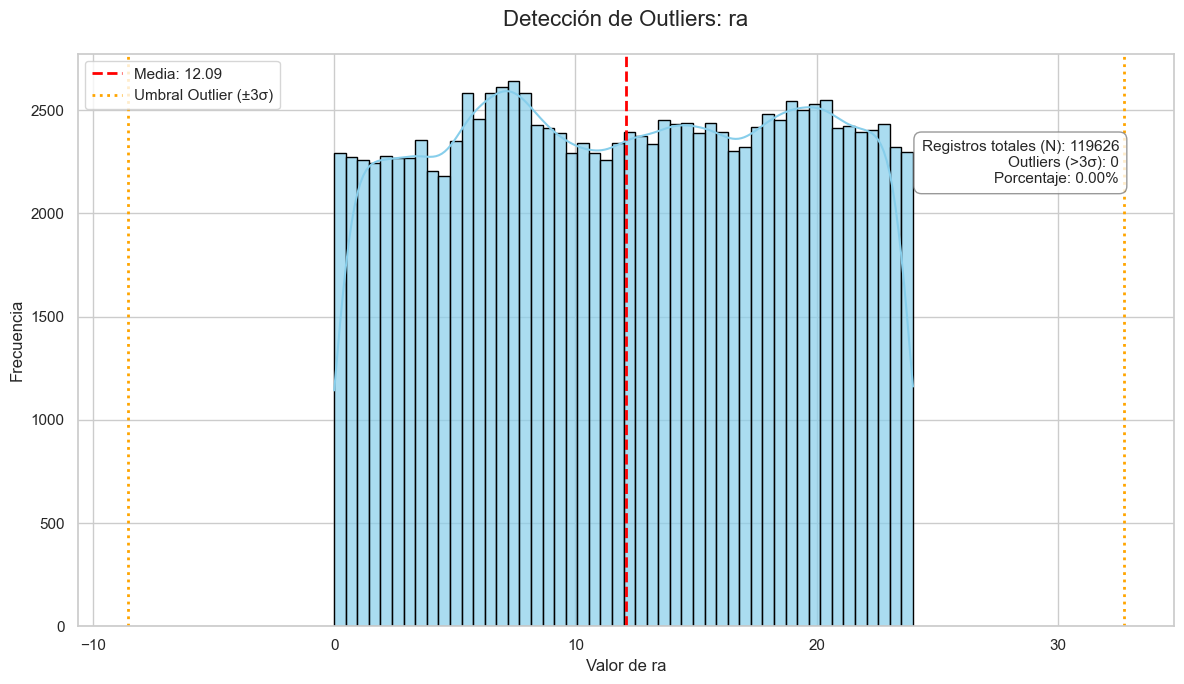

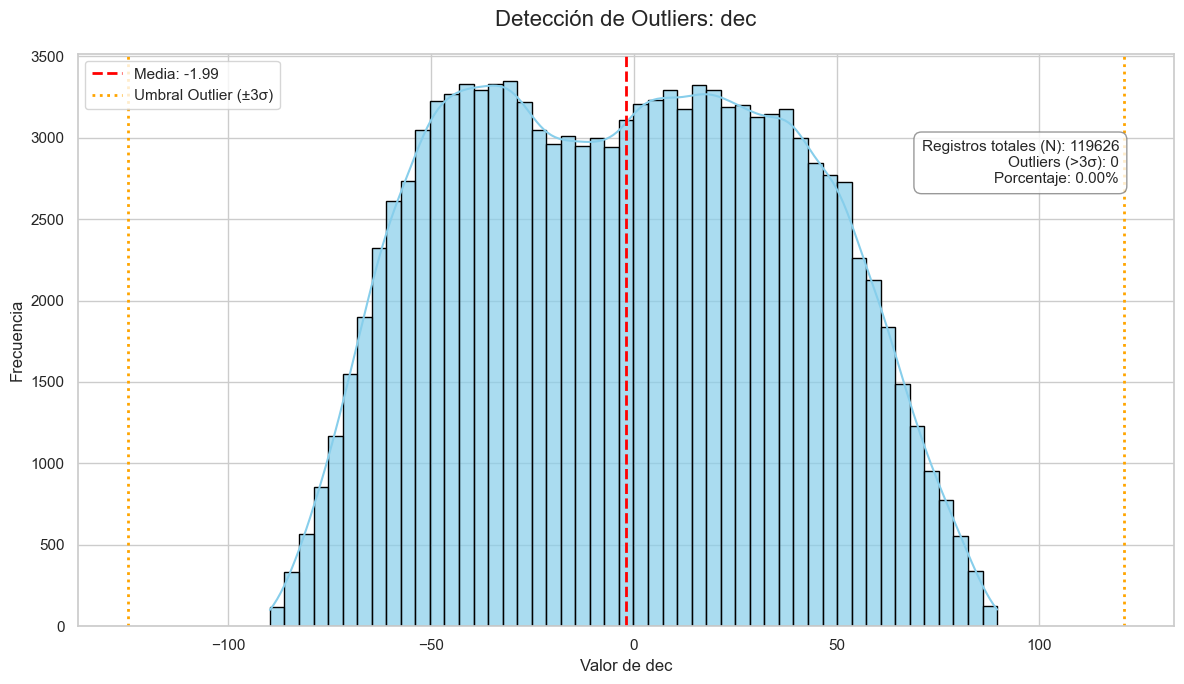

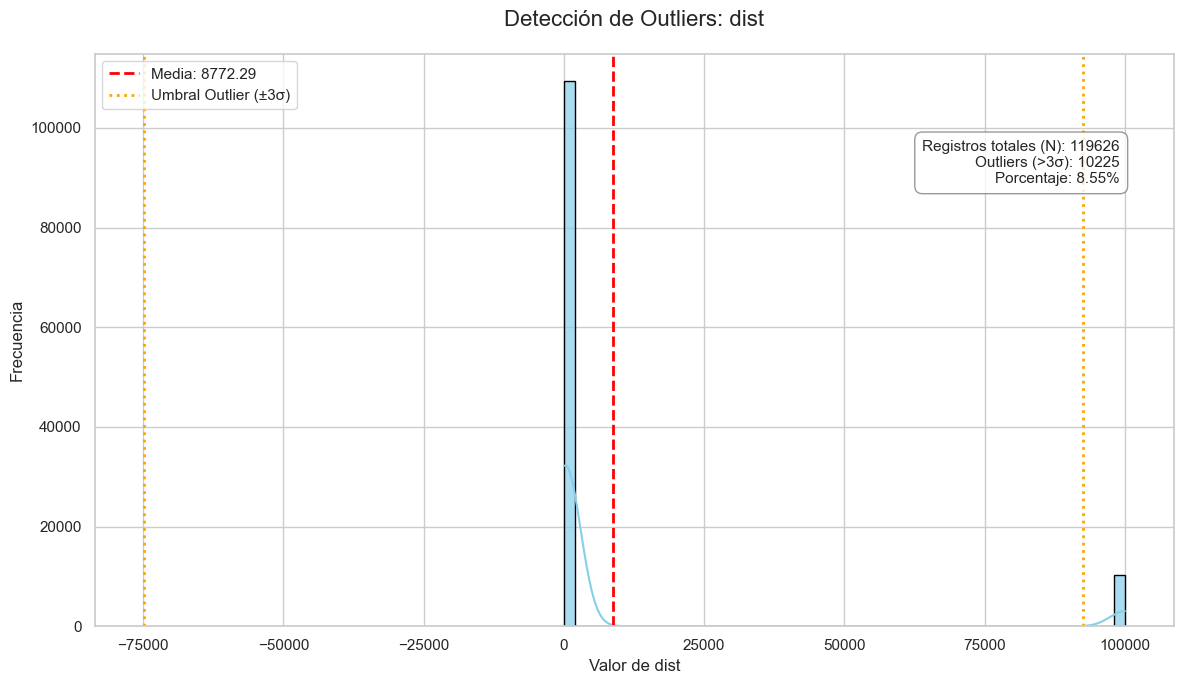

In [3]:
def analizar_outliers_histograma(df, columna, bins=30, titulo=None):

    # Preparamos los datos que luego utilizaremos 
    datos = df[columna].dropna() #quitamos nulos de la columna en estudio
    total_n = len(datos)          # Número total de registros
    media = datos.mean() # Media de la columna
    desviacion = datos.std() #Desvacion 
    
    # Calculamos los Outliners que estan por encima de  3-sigma
    fuera_de_rango = datos[abs(datos - media) > 3 * desviacion]
    conteo_outliers = len(fuera_de_rango)
    porcentaje_outliers = (conteo_outliers / total_n) * 100 #porcentaje del total de registros para ver si son muchos
    
    # Configuramos el grafico
    plt.figure(figsize=(12, 7)) # Tamaño
    sns.set_theme(style="whitegrid") 
    
    # Histograma
    sns.histplot(datos, bins=bins, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Pintamos las lineas de referencia del grafico para, deuna forma mas visual ver donde estan colocados los datos
    plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}') # Media
    #Umbrales de 3-sigma, por arriba y por abajo
    plt.axvline(media + 3*desviacion, color='orange', linestyle=':', linewidth=2, label='Umbral Outlier (±3σ)')
    plt.axvline(media - 3*desviacion, color='orange', linestyle=':', linewidth=2)

    # Cuadro de texto con los calculos realizados
    stats_text = (
        f"Registros totales (N): {total_n}\n"
        f"Outliers (>3σ): {conteo_outliers}\n"
        f"Porcentaje: {porcentaje_outliers:.2f}%"
    )
    
    # Colocamos el texto en la parte superior derecha del gráfico
    plt.text(0.95, 0.85, stats_text, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

    # Resto de etiquetas.
    plt.title(titulo if titulo else f"Detección de Outliers: {columna}", fontsize=16, pad=20)
    plt.xlabel(f"Valor de {columna}", fontsize=12)
    plt.ylabel("Frecuencia", fontsize=12)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

#deteccion de errores  las cordenadas ecuatoriales
analizar_outliers_histograma(df, 'ra', bins=50) # Valores entre 0 y 24
analizar_outliers_histograma(df, 'dec', bins=50) # Valores entre -90 y 90
analizar_outliers_histograma(df, 'dist', bins=50) # no puede tener valors negativos

En el análisis de valores atípicos (outliers) relativos a la distancia, se ha determinado no descartar los registros que exceden el umbral estadístico. En astrofísica, estas mediciones pueden ser físicamente correctas dada la vasta escala del catálogo; no obstante, se ha realizado una validación de integridad para asegurar la ausencia de valores negativos, los cuales carecerían de sentido físico.

# Enriquecimiento del Dataset

Después de la carga de datos, en este apartado añadiremos las columnas, ya sean calculadas o por referencia para el enriquecimiento y normalización de los datos. 
Estos son los datos añadidos al conjunto de datos:
- Normalización de las Constelaciones
- Normalización Nombre de estrellas
- Cálculo de temperatura de las estrellas
- Cálculo del color de las estrellas en función de su temperatura
- Cálculo del radio estelar (tamaño en referencia al sol)
- Distancia (años luz)


## Normalización Constelaciones

La normalización de las constelaciones consiste en crear una columna que contenga los nombre completos de las constelaciones en español

Ori -> Orion

And -> Andromeda

Peg -> Pegaso

...

In [4]:
def normalizar_constelaciones(df):
    # Diccionario, en español, para el Mapeo de las constelaciones creado con ayuda de Gemini sobre las 90 cosntelaciones que aparecen en el conjunto de datos.
    mapping_es = {
        "And": "Andrómeda", "Ant": "Máquina Neumática", "Aps": "Ave del Paraíso", 
        "Aqr": "Acuario", "Aql": "Águila", "Ara": "Altar", "Ari": "Aries", 
        "Aur": "Cochero", "Boo": "Boyero", "Cae": "Cincel", "Cam": "Jirafa", 
        "Cnc": "Cáncer", "CVn": "Lebreles", "CMa": "Can Mayor", "CMi": "Can Menor", 
        "Cap": "Capricornio", "Car": "Quilla", "Cas": "Casiopea", "Cen": "Centauro", 
        "Cep": "Cefeo", "Cet": "Ballena", "Cha": "Camaleón", "Cir": "Compás", 
        "Col": "Paloma", "Com": "Cabellera de Berenice", "CrA": "Corona Austral", 
        "CrB": "Corona Boreal", "Crv": "Cuervo", "Crt": "Copa", "Cru": "Cruz del Sur", 
        "Cyg": "Cisne", "Del": "Delfín", "Dor": "Dorado", "Dra": "Dragón", 
        "Equ": "Caballito", "Eri": "Erídano", "For": "Horno", "Gem": "Géminis", 
        "Gru": "Grulla", "Her": "Hércules", "Hor": "Reloj", "Hya": "Hidra Hembra", 
        "Hyi": "Hidra Macho", "Ind": "Indio", "Lac": "Lagarto", "Leo": "Leo", 
        "LMi": "Leo Menor", "Lep": "Liebre", "Lib": "Libra", "Lup": "Lobo", 
        "Lyn": "Lince", "Lyr": "Lira", "Men": "Mesa", "Mic": "Microscopio", 
        "Mon": "Unicornio", "Mus": "Mosca", "Nor": "Escuadra", "Oct": "Octante", 
        "Oph": "Ofiuco", "Ori": "Orión", "Pav": "Pavo", "Peg": "Pegaso", 
        "Per": "Perseo", "Phe": "Fénix", "Pic": "Caballete del Pintor", "Psc": "Piscis", 
        "PsA": "Pez Austral", "Pup": "Popa", "Pyx": "Brújula", "Ret": "Retículo", 
        "Sge": "Flecha", "Sgr": "Sagitario", "Sco": "Escorpio", "Scl": "Escultor", 
        "Sct": "Escudo", "Ser": "Serpiente", "Sex": "Sextante", "Tau": "Tauro", 
        "Tel": "Telescopio", "Tri": "Triángulo", "TrA": "Triángulo Austral", 
        "Tuc": "Tucán", "UMa": "Osa Mayor", "UMi": "Osa Menor", "Vel": "Vela", 
        "Vir": "Virgo", "Vol": "Pez Volador", "Vul": "Zorra"
    }

    # Aplicamos el mapeo al DataFrame
    df['con_normalizada'] = df['con'].map(mapping_es).fillna(df['con'])
    
    return df


df = normalizar_constelaciones(df)


## Normalización Nombres Estrellas

Una de las variables fundamentales para la interpretación de los resultados es la columna ***proper***, que contiene el nombre común de las estrellas (ej. Sirio, Betelgeuse). Sin embargo,esta columna presenta una alta proporción de valores nulos (NaN).
Para mejorar la legibilidad del dataset se procede a nombrar estrellas sin nombre. 
Lo que haremos es prioriza el nombre propio (identidad histórica); en su defecto, recurriremos a la segunda forma comun de nombrar las estrellas ( Beta-Ori, Alfa-Cent...), para ello añadiéndole la abreviatura de la constelación a la columna del catalgo de Bayer,y  por ultimo, generaremos un identificador basado en el índice único (ID).Así todas las estrellas tendrán su identificador diferente en el nombre.


In [5]:
# Modificamos los nombres segun criterio definido anteriormente
def aplicar_nombres_estrellas(df):

    def construir(row):
        # Primer If, si tienen nommbre comun en proper lo dejamos
        if pd.notna(row['proper']) and str(row['proper']).strip() != "":
            return str(row['proper']).strip()
        
        # Segundo If , si no tiene nombre comun 
        elif pd.notna(row['bayer']) and str(row['bayer']).strip() != "":
            # Combinamos la letra de Bayer con la constelación abreviada
            return f"{row['bayer']} {row['con']}"
        
        # Tercer If construimos el nombre de la estrella Sin_Nombre + id 
        else:
            return f"Sin nombre_{row['id']}"

    # Aplicamos la función fila por fila al df creando la columna nombre
    df['nombre'] = df.apply(construir, axis=1)
    
    return df

df = aplicar_nombres_estrellas(df)

## Cálculo de la Temperatura de la estrella

Ahora añadiremos una nueva columna "temperatura_K" sera una temperatura aproximada de la estrella usando el indice de color a traves de lo que se conoce como la Relacion de Ballesteros. Esta expresión permite derivar la temperatura superficial a partir del índice de color fotométrico $B-V$ (columna ci del catálogo HYG) 

$$T = 4600 \left( \frac{1}{0.92(B-V) + 1.7} + \frac{1}{0.92(B-V) + 0.62} \right)$$

Esta formula es una funcion continua que tiene una elevada precision para las estrellas de la secuencia Principal, para las estrellas mas exoticas o curiosas esa precision es algo menor. 

Sobre el trabajo de Ballesteros es posible conocer mas informacion aqui:
[Referencia: Ballesteros (2012) - EPL 97 34008](https://arxiv.org/pdf/1201.1809)




In [6]:
def calcular_temperatura(bv):
    # Aplicación de la fórmula
    term1 = 1 / (0.92 * bv + 1.7)
    term2 = 1 / (0.92 * bv + 0.62)
    return 4600 * (term1 + term2)

In [7]:
df['temperatura_K'] = df['ci'].apply(calcular_temperatura)

In [8]:
df.head()

,id,hip,hd,hr,gl,bf,proper,ra,dec,dist,...,comp,comp_primary,base,lum,var,var_min,var_max,con_normalizada,nombre,temperatura_K
0,0,NaN,NaN,NaN,NaN,NaN,Sol,0.000000,0.000000,0.0000,...,1,0,NaN,1.000000,NaN,NaN,NaN,NaN,Sol,5756.588113
1,1,1.0,224700.0,NaN,NaN,NaN,NaN,0.000060,1.089009,219.7802,...,1,1,NaN,9.638290,NaN,NaN,NaN,Piscis,Sin nombre_1,6471.667826
2,2,2.0,224690.0,NaN,NaN,NaN,NaN,0.000283,-19.498840,47.9616,...,1,2,NaN,0.392283,NaN,NaN,NaN,Ballena,Sin nombre_2,4745.140425
3,3,3.0,224699.0,NaN,NaN,NaN,NaN,0.000335,38.859279,442.4779,...,1,3,NaN,386.901132,NaN,NaN,NaN,Andrómeda,Sin nombre_3,10368.595588
4,4,4.0,224707.0,NaN,NaN,NaN,NaN,0.000569,-51.893546,134.2282,...,1,4,NaN,9.366989,NaN,NaN,NaN,Fénix,Sin nombre_4,7044.130880


## Cálculo del color de la estrella en funcion de la temperatura

Para representar las estrellas de forma algo mas real, se ha implementado un algoritmo que traduce la temperatura superficial calculada en un código de color visual. Este procedimiento se fundamenta en la **[Ley de Desplazamiento de Wien,]( https://rspec-astro.com/download/Weins-Law-not-so-simple-paper.pdf)** la cual establece que la longitud de onda de máxima emisión de un cuerpo negro es inversamente proporcional a su temperatura absoluta. De este modo, la física de radiación explica por qué las estrellas más calientes desplazan su pico de emisión hacia el espectro azul (longitudes de onda cortas), mientras que las más frías lo hacen hacia el espectro rojo (longitudes de onda largas)

Para la ejecución de este modelo, se han definido límites térmicos basados en el estándar de las **Clases Espectrales de la Unión Astronómica Internacional (IAU).** Estos intervalos permiten establecer una correlación directa entre la temperatura efectiva —obtenida mediante la Relación de Ballesteros— y la apariencia cromática de la estrella.



In [9]:
def color_normalizado(temperatura):
    # Le pasamos la temperatura de la estrella en K ynos devuelve el color normalizado
    if pd.isna(temperatura):
        return "Desconocido" # para los casos que no tenga temperatura
    limites_temperaturas = [0, 3700, 5200, 6000, 7500, 10000, 30000, 100000] #Creamos los tramos para los colores , es decir estrellas entre 0 y 3700K son de color Rojo. Segun (IAU)
    labels = ['Rojo', 'Naranja', 'Amarillo', 'Blanco Amarillento', 'Blanco', 'Blanco Azulado', 'Azul'] # Etiquetas que apareceran en la columna nueva
    # Lógica de clasificación
    for i in range(len(limites_temperaturas) - 1):
        if limites_temperaturas[i] <= temperatura < limites_temperaturas[i+1]:
            return labels[i]
            
    return "Azul" # Todos los valores mayores de 100000K

In [10]:
# Creamos la nueva columna con el dato
df['color_estrella'] = df['temperatura_K'].apply(color_normalizado)

In [11]:
df.head()

,id,hip,hd,hr,gl,bf,proper,ra,dec,dist,...,comp_primary,base,lum,var,var_min,var_max,con_normalizada,nombre,temperatura_K,color_estrella
0,0,NaN,NaN,NaN,NaN,NaN,Sol,0.000000,0.000000,0.0000,...,0,NaN,1.000000,NaN,NaN,NaN,NaN,Sol,5756.588113,Amarillo
1,1,1.0,224700.0,NaN,NaN,NaN,NaN,0.000060,1.089009,219.7802,...,1,NaN,9.638290,NaN,NaN,NaN,Piscis,Sin nombre_1,6471.667826,Blanco Amarillento
2,2,2.0,224690.0,NaN,NaN,NaN,NaN,0.000283,-19.498840,47.9616,...,2,NaN,0.392283,NaN,NaN,NaN,Ballena,Sin nombre_2,4745.140425,Naranja
3,3,3.0,224699.0,NaN,NaN,NaN,NaN,0.000335,38.859279,442.4779,...,3,NaN,386.901132,NaN,NaN,NaN,Andrómeda,Sin nombre_3,10368.595588,Blanco Azulado
4,4,4.0,224707.0,NaN,NaN,NaN,NaN,0.000569,-51.893546,134.2282,...,4,NaN,9.366989,NaN,NaN,NaN,Fénix,Sin nombre_4,7044.130880,Blanco Amarillento


Ahora definimos un color hexadecimal para cada uno de los colores anteriores que utilizaremos en las representaciones

In [12]:
def color_hex(color_normalizado): 
    # Aqui convertimos el color normalizado en un color hexadecimal atraves de una lista
    color_map_hex = {
        'Rojo': '#ff3300',
        'Naranja': '#ff9933',
        'Amarillo': '#ffff66',
        'Blanco Amarillento': '#ffffcc',
        'Blanco': '#ffffff',
        'Blanco Azulado': '#ccf2ff',
        'Azul': '#33ccff'
    }
    color_hex= color_map_hex.get(color_normalizado, '#000000')
    return color_hex


In [13]:
# Creamos la nueva columna para el color en hexadecimal aplicando a la columna color_estrella la funcion creada
df['color_hex'] = df['color_estrella'].apply(color_hex)

In [14]:
df.head()

,id,hip,hd,hr,gl,bf,proper,ra,dec,dist,...,base,lum,var,var_min,var_max,con_normalizada,nombre,temperatura_K,color_estrella,color_hex
0,0,NaN,NaN,NaN,NaN,NaN,Sol,0.000000,0.000000,0.0000,...,NaN,1.000000,NaN,NaN,NaN,NaN,Sol,5756.588113,Amarillo,#ffff66
1,1,1.0,224700.0,NaN,NaN,NaN,NaN,0.000060,1.089009,219.7802,...,NaN,9.638290,NaN,NaN,NaN,Piscis,Sin nombre_1,6471.667826,Blanco Amarillento,#ffffcc
2,2,2.0,224690.0,NaN,NaN,NaN,NaN,0.000283,-19.498840,47.9616,...,NaN,0.392283,NaN,NaN,NaN,Ballena,Sin nombre_2,4745.140425,Naranja,#ff9933
3,3,3.0,224699.0,NaN,NaN,NaN,NaN,0.000335,38.859279,442.4779,...,NaN,386.901132,NaN,NaN,NaN,Andrómeda,Sin nombre_3,10368.595588,Blanco Azulado,#ccf2ff
4,4,4.0,224707.0,NaN,NaN,NaN,NaN,0.000569,-51.893546,134.2282,...,NaN,9.366989,NaN,NaN,NaN,Fénix,Sin nombre_4,7044.130880,Blanco Amarillento,#ffffcc


## Cálculo del Radio Estelar

Para poder comparar los tamaños fisicos de las estrellas (Radio Estelar) entre ellas, necesitamos calcular primero el radio de cada una, ya que en el dataset no esta este dato. 
Lo que haremos sera calcular el Radio en comparacion con el Sol($R/R_{\odot}$) usando la luminosidad y la tempuratura. Para ello aplicamos la ley de Stefan-Boltzman.
$$L = 4\pi R^2 \sigma T_{eff}^4$$Donde $\sigma$ es la constante de Stefan-Boltzmann. Para facilitar la comparación con nuestro sistema, expresamos esta relación en unidades solares ($L_{\odot}, R_{\odot}, T_{\odot}$), lo que nos permite simplificar las constantes y obtener la fórmula final del radio:$$\frac{R}{R_{\odot}} = \sqrt{\frac{L}{L_{\odot}}} \left( \frac{T_{\odot}}{T_{eff}} \right)^2$$
Despejando el Radio Estelar ($R$), obtenemos la fórmula aplicada en nuestro código:$$R = \sqrt{L_{rel}} \cdot \left( \frac{T_{\odot}}{T_{eff}} \right)^2$$

Donde:

$R$ se expresa en Radios Solares ($R_{\odot}$).

$L_{rel}$ es la luminosidad de la estrella respecto a la del Sol ($L/L_{\odot}$).

$T_{\odot}$ es la temperatura de referencia del Sol calculada en el propio dataset (aprox. 5778 K)

In [15]:
def radio_estelar(luminosidad, temperatura):

    #Como hemos comentado el radio estelar sera una medida en funcion del radio solar, es por ello que utilizaremos los datos del sol que hay en el dataset
    # El sol se encuentra en el primer registro de este.
    #Los  parametros de entrada ya los tenemos calculados dentro del dataset, corresponden a las nuevas columnas creadas para cada estrella
    t_sol_dataset = df.loc[df['id'] == 0, 'temperatura_K'].values[0]
    
    # Aplicamos la relación R = sqrt(L) * (T_sol / T)^2
    radio = np.sqrt(luminosidad) * (t_sol_dataset / temperatura)**2

    return radio


In [16]:
# Añadimos la columna al df, podemos comprobar el resultado viendo que para el sol el dradio estelar es 1, ya que como hemos comentado esta en funcion de radio solar
df['radio_estelar'] = radio_estelar(df['lum'], df['temperatura_K'])

In [17]:
df.head()

,id,hip,hd,hr,gl,bf,proper,ra,dec,dist,...,lum,var,var_min,var_max,con_normalizada,nombre,temperatura_K,color_estrella,color_hex,radio_estelar
0,0,NaN,NaN,NaN,NaN,NaN,Sol,0.000000,0.000000,0.0000,...,1.000000,NaN,NaN,NaN,NaN,Sol,5756.588113,Amarillo,#ffff66,1.000000
1,1,1.0,224700.0,NaN,NaN,NaN,NaN,0.000060,1.089009,219.7802,...,9.638290,NaN,NaN,NaN,Piscis,Sin nombre_1,6471.667826,Blanco Amarillento,#ffffcc,2.456393
2,2,2.0,224690.0,NaN,NaN,NaN,NaN,0.000283,-19.498840,47.9616,...,0.392283,NaN,NaN,NaN,Ballena,Sin nombre_2,4745.140425,Naranja,#ff9933,0.921790
3,3,3.0,224699.0,NaN,NaN,NaN,NaN,0.000335,38.859279,442.4779,...,386.901132,NaN,NaN,NaN,Andrómeda,Sin nombre_3,10368.595588,Blanco Azulado,#ccf2ff,6.063040
4,4,4.0,224707.0,NaN,NaN,NaN,NaN,0.000569,-51.893546,134.2282,...,9.366989,NaN,NaN,NaN,Fénix,Sin nombre_4,7044.130880,Blanco Amarillento,#ffffcc,2.043975


## Cálculo de la Distancia(Años Luz)

Para este caso disponemos de la distancia de la estrella en Parsec, por lo que solo es necesario pasarlo a años Luz que es una unidad mas familiar
$$1 \text{ pc} \approx 3.26156 \text{ años luz}$$

**Definición de Pársec:** Unidad de distancia equivalente a la distancia desde la cual el radio de la órbita terrestre subtiende un ángulo de un segundo de arco.
> 
> *Fuente: [Sociedad Española de Astronomía (SEA)](https://www.sea-astronomia.es/glosario/parsec)*

In [18]:
df['distancia_años_luz'] = df['dist'] * 3.26156

# Visualización de Datos

Continuamos con las funciones que nos permitiran algunas visualizaciones de los datos,  estas son las funciones realizadas:
- Diagrama Hertzsprung-Russell (HR)  color vs. luminosidad.
- Posición de las estrellas respecto al Sol.
- Posición de las estrellas segun su declinacion y ascension recta (Lo que vemos en el cielo), Carta estelar


Previamente para poder hacer la visualización de distintos conjuntos de estrellas definiremos unos df caracteristicos que utilizaremos para visualizar y que podrían servir para diferentes observaciones. 
este seria la forma de trabajar, crear df con diferentes caracteristicas paa luego aplicar las diferentes funciones.

In [19]:
# Dataframes con las estrellas por Constelacion
df_Orion= df[df['con'] == 'Ori']
df_pegaso = df[df['con'] == 'Peg']
df_OsaMayor = df[df['con'] == 'UMa']
df_Serpiente = df[df['con'] == 'Ser']
df_Scorpion = df[df['con'] == 'Sco']
# Estrellas visibles desde la tierra sin instrumentos
df_estrellas_visibles = df[df['mag'] < 6]
# Estrellas Amarillas como el Sol
df_estrellas_Amarillas = df[df['color_estrella'] == 'Amarillo']
# estrellas con nombre conocidos 
df_estrellas_conocidas = df[df['proper'].notna()]
# Estrellas del hemisferio norte su dec es > 90
df_estrellas_h_norte=df[df['dec'] >= 0]
# Estrellas hemisferio norte , mag < 6 , conocidas
df_Observacion1=df[(df['dec'] >= 0) & (df['mag'] < 6) & (df['proper'].notna())]

## Diagrama Hertzsprung-Russell (HR)  color vs. luminosidad.

La primera funcion de visualización consiste en el famoso diagrama Hertzsprung-Russell (HR) color vs. Luminosidad que nos servira para comprobar que hemos calculado correctamente las variables(Temperatura, Luminosidad, radio y Color), ya que se unen en esta grafica. 
El Diagrama HR es una herramienta gráfica que muestra la relación entre la Luminosidad (o magnitud absoluta) de las estrellas y su Temperatura efectiva (o tipo espectral/índice de color). Fue creado de forma independiente por Ejnar Hertzsprung y Henry Norris Russell a principios del siglo XX
Nos permite entender la vida de las estrellas, en el se puede:
- Identificar etapas evolutivas, lo que nos permite ver la vida de las estrellas.
- Determinar la edad de las estrellas
- Visualizar el tamaño de estas.
Este seria el diagrama correcto

Acontinuacion se muestra el diagrama HR para poder comprobar los resultado de la funcion

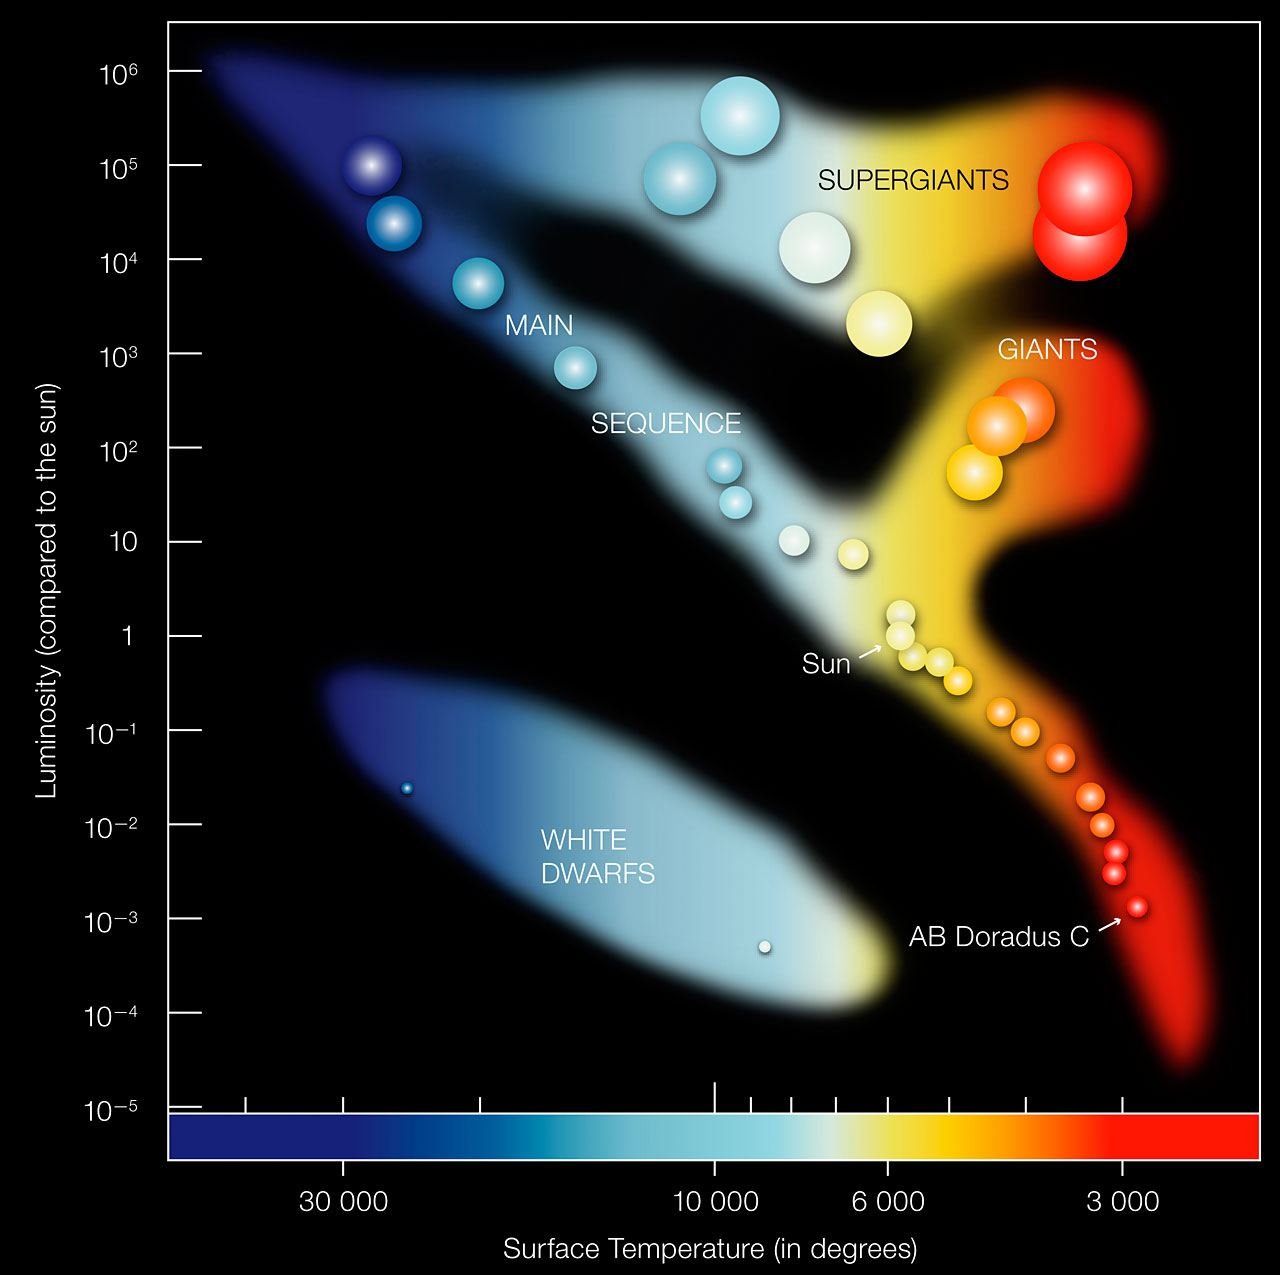

European Southern Observatory. (s. f.). *Hertzsprung-Russell Diagram* [Ilustración].
<https://www.eso.org/public/images/eso0728c/>

Crédito: ESO. Reproducida bajo licencia
[Creative Commons Reconocimiento 4.0 Internacional (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/)


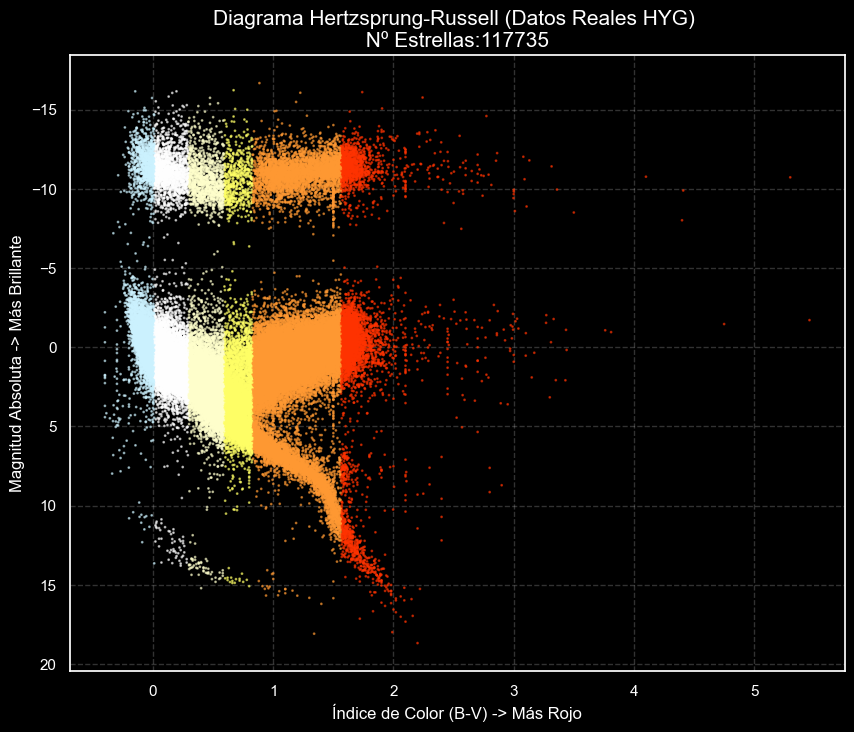

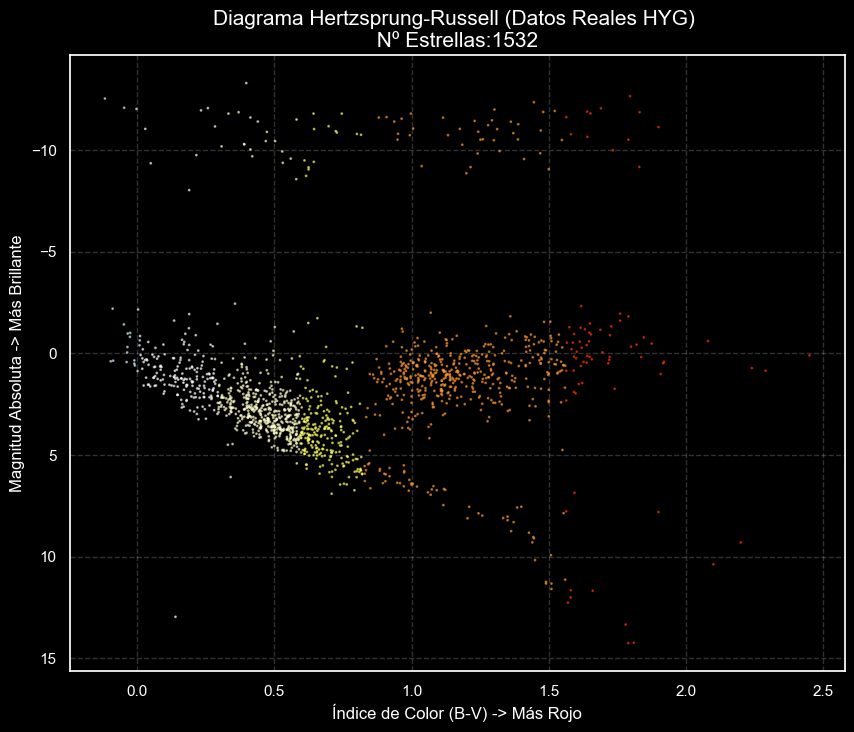

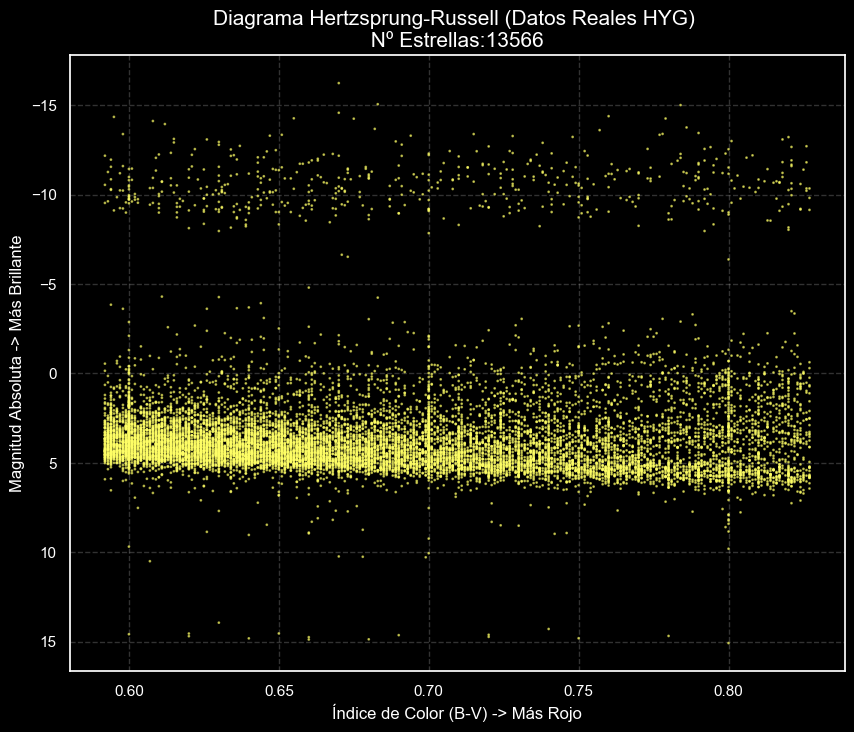

In [20]:

def representar_diagrama_hr(df_input):

    # Eliminamos los registros que puedan tener errores.
    columnas_necesarias = ['ci', 'absmag', 'color_hex']
    df_plot = df_input.dropna(subset=columnas_necesarias).copy()

    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(10, 8)) #Tamaño y color del grafico


    scatter = ax.scatter(df_plot['ci'], df_plot['absmag'], 
        c=df_plot['color_hex'], # Usamos nuestra columna de colores para que las pinte de forma aprox a su color real
        s=1,# Tamaño de punto, pequeño para ver la densidad
        alpha=0.6)  #Transparencia de los puntos

    # Para representarlo como se suele mostra , es necesario cambiar el eje y para que las mas brillantes esten arriba (Magnitus absoluta)

    ax.invert_yaxis()

    # arregalmos un poco el grafico
    n_estrellas = len(df_plot) # para ver el numero de estrellas representadas
    ax.set_title(f'Diagrama Hertzsprung-Russell (Datos Reales HYG) \n Nº Estrellas:{n_estrellas} ', fontsize=15)
    ax.set_xlabel('Índice de Color (B-V) -> Más Rojo', fontsize=12)
    ax.set_ylabel('Magnitud Absoluta -> Más Brillante', fontsize=12)
    
    # Ponemos el grid
    ax.grid(True, linestyle='--', alpha=0.2)
    plt.show()

#Ejemplos para Df concretos definidos previamente
representar_diagrama_hr(df) # este es el que corresponde con el de la imagen anterior
representar_diagrama_hr(df_Serpiente) # para la constelacion de La Serpiente
representar_diagrama_hr(df_estrellas_Amarillas) #

## Posición de las estrellas



Para la interpretación de la distribución espacial de la muestra se ha desarrollado la siguiente función. 

Esta herramienta realiza una representación aproximada de las posiciones de las estrellas en un gráfico con tres dimensiones $(x, y, z)$ desde un análisis heliocéntrico, es decir el Sol se encuentra en el punto (0,0,0). Esto nos permite apreciar la densidad estelar en el entorno solar.
En el grafico colocaremos siempre el sol para ver su ubicación y utilizarlo de referencia. Se ha añadido el color de la estrella en la representación calculado previamente para darle una mejor apariencia.

Para crear esta funcion se ha consultado la pagina oficial de matplotlib, para ampliar los conocimientos en los graficos 3D

[Libreria matplotlib](https://matplotlib.org/stable/users/explain/toolkits/mplot3d.html)

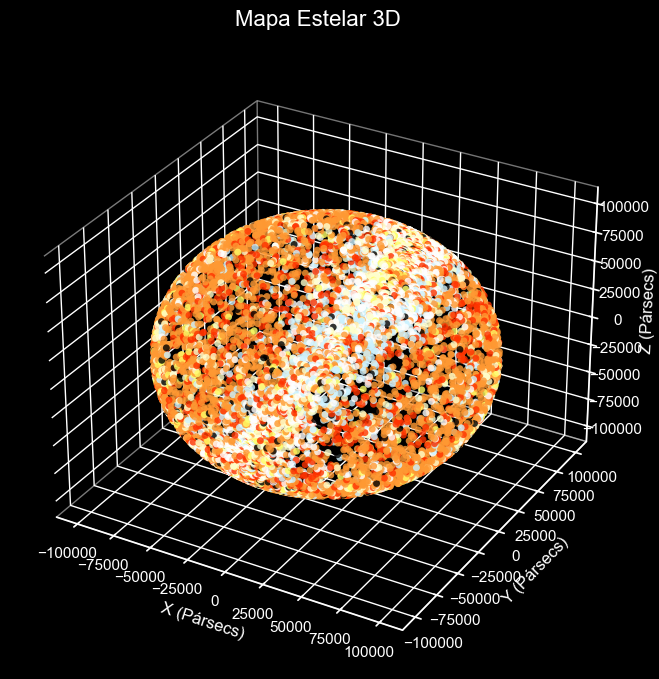

In [21]:
def representar_3d_estrellas(df_input):

    fig = plt.figure(figsize=(10, 8)) # Ajustamos el tamaño del grafico
    ax = fig.add_subplot(111, projection='3d')
    
    # Todo al negro que estamos hablando del espacio
    ax.set_facecolor('black')
    fig.set_facecolor('black')
    
    # Dibujamos las estrellas del df de entrada
    ax.scatter(df_input['x'], df_input['y'], df_input['z'],
               c=df_input['color_hex'], # color el que le corresponda
               s=25, 
               alpha=0.8, 
               edgecolors='none')
    
    # Para poder localizar el sol lo dibujamos , en lugar de un punto una estrella de color amarillo y l eponemos la etiqueta
    # este grafico esta en Parsecs, si quisieramos ponerlo en años luz tendriamos que transformar las tres cordenadas(x,y,z) a años luz p= 3,26...años luz
    ax.scatter([0], [0], [0], color='yellow', s=250, marker='*', 
               edgecolors='white', label='SOL')

    # Preparamos el resto del grafico al gusto
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.zaxis.label.set_color('white')
    ax.tick_params(colors='white')
    
    
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(color='gray', linestyle='--', alpha=0.3)

    ax.set_title("Mapa Estelar 3D", color='white', fontsize=16, pad=20)

    ax.set_xlabel('X (Pársecs)')
    ax.set_ylabel('Y (Pársecs)')
    ax.set_zlabel('Z (Pársecs)')

    plt.show()

representar_3d_estrellas(df)



Una vez generada la representación global del catálogo (que abarca la totalidad de las estrellas del dataset distribuidas en la esfera celeste), se procede a realizar un análisis comparativo de dos regiones de especial interés astronómico: las constelaciones de Orión y Escorpio.

La elección no es arbitraria ya que ambas constelaciones se encuentran en posiciones prácticamente opuestas en la esfera celeste. Mientras que Orión es la protagonista del cielo de invierno en el hemisferio norte, Escorpio domina las noches de verano, con estas constelacione spodemos hacer una pequeña comprobacion observado que se encuentra a los dos lados del sol. Te invito a ver el siguiente video corto(47s). 


**[La leyenda de Orión y Escorpión](https://www.youtube.com/watch?v=Un4De4iAXTU&t=47s)**


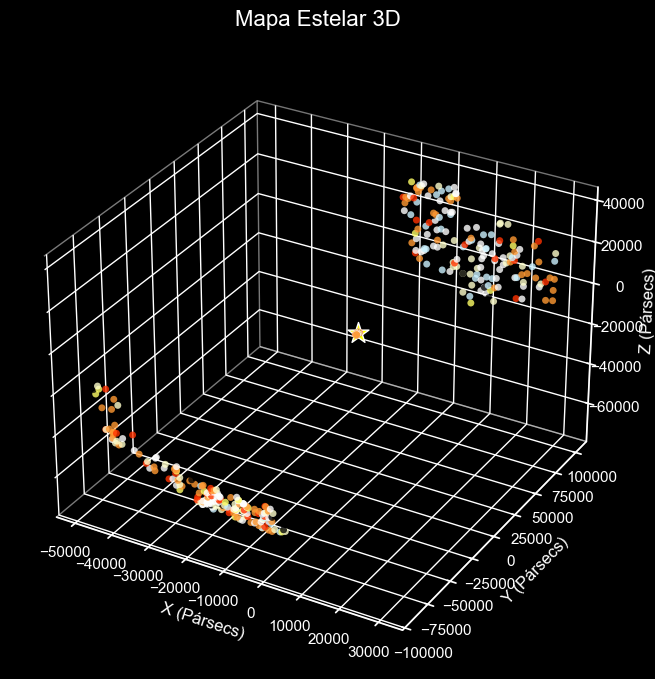

In [22]:
df_Orion_Escorpio = pd.concat([df_Orion, df_Scorpion])
representar_3d_estrellas(df_Orion_Escorpio)

## Dibujamos las constelaciones


Para facilitar el análisis visual de regiones específicas y constelaciones, se ha desarrollado la función ***representar_firmamento_centrado***. El objetivo de este algoritmo es emular la apariencia de las cartas estelares tradicionales, proyectando la posición de los astros en un plano bidimensional definido por sus coordenadas ecuatoriales.
Fundamentos de la Visualización:

1.	**Coordenadas Ecuatoriales:** La función utiliza la Ascensión Recta (RA) y la Declinación (Dec) para posicionar cada objeto sobre la bóveda celeste. Estas variables vienen recogidas dentro del Dataset por las columnas ‘ra’ y ‘dec’ Este sistema de coordenadas es el estándar en astronomía profesional para localizar objetos independientemente de la ubicación del observador en la Tierra.
  
2.	**Escalado por Magnitud Aparente:** En lugar de representar todas las estrellas con un tamaño uniforme, se ha implementado una fórmula de escalada inversa basada en la magnitud física:
$$Tamaño \propto (Mag_{max} - Mag_{i} + 1)^3$$
Esto permite que las estrellas más brillantes (menor magnitud) destaquen visualmente con mayor diámetro, imitando la respuesta del ojo humano y de los sensores ópticos.


3.	**Fidelidad Cromática:** Cada punto integra el color hexadecimal calculado previamente a partir de la temperatura efectiva, permitiendo identificar de un vistazo la clase espectral predominante en la constelación.

A la funcion se le ha añadido como parametro de entrada ademas de df con las estrellas a representar, la magnitud maxima que tiene que tener las estrellas para ser representadas


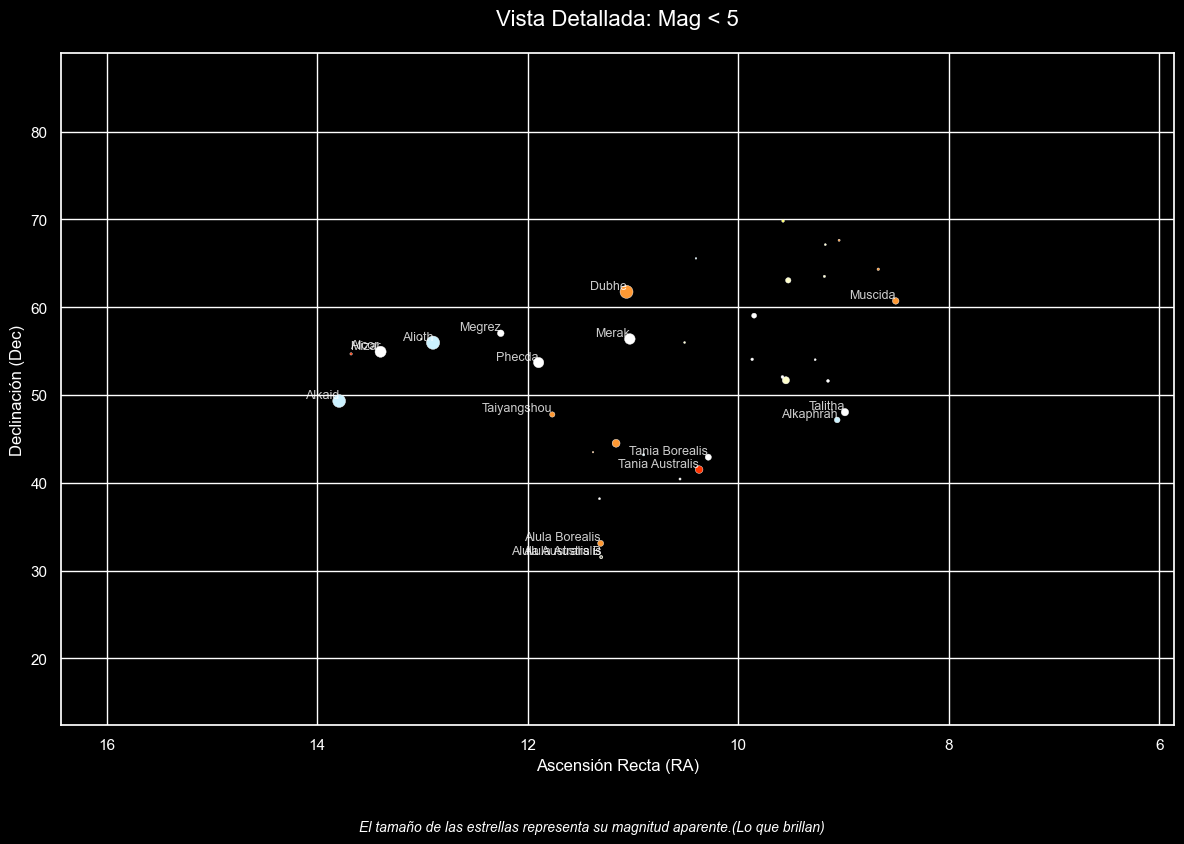

In [35]:
def representar_firmamento_centrado(df_input, magnitud = 6):

    # Nos quedamos solo con las que cumplan con la magnitud aparente que queremos. (<6 visibles ccon el ojo humano)
    df_n = df_input[df_input['mag'] < magnitud]
    # lo siguiente es quitar el Sol
    df_n = df_n[df_n['nombre'] != 'Sol']

    # se puede dar el caso que en el df no contenga estrellas con esa magnitud.
    if df_n.empty:
        print(f"No hay estrellas con magnitud menor que {magnitud}")
        return
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_facecolor('black')
    fig.set_facecolor('black')
    
    # Calculamos el tamaño del punto de la estrella en funcion de la magnitud
    max_mag = df_n['mag'].max()
    tamanos = (max_mag - df_n['mag'] + 1) ** 3
    
    # Calculamos los valore max y min de las dos variables para ajustar el grafico y que se ve lo mas grande posible
    ra_min, ra_max = df_n['ra'].min(), df_n['ra'].max()
    dec_min, dec_max = df_n['dec'].min(), df_n['dec'].max()
    
    # Calculamos el rango
    ra_rango = ra_max - ra_min if ra_max != ra_min else 1
    dec_rango = dec_max - dec_min if dec_max != dec_min else 1
    
    ra_margen = ra_rango * 0.5
    dec_margen = dec_rango * 0.5
    
    # LIMITES EXACTOS
    ra_lim_min = ra_min - ra_margen
    ra_lim_max = ra_max + ra_margen
    dec_lim_min = dec_min - dec_margen
    dec_lim_max = dec_max + dec_margen
        
    # 3. Representación
    ax.scatter(df_n['ra'], df_n['dec'], 
               c=df_n['color_hex'], 
               s=tamanos *1.2, # tamaño en funcion de su magnitud
               alpha=1.0, 
               edgecolors='white', 
               linewidths=0.3)

    # añadimos las etiquetas de las estrellas que tienen nombre 
    for _, fila in df_n.iterrows():
        # Verificamos que la columna 'proper' (o 'name') tenga contenido
        if pd.notna(fila['proper']) and str(fila['proper']).strip() != "":
            ax.text(fila['ra'], fila['dec'], 
                    str(fila['proper']), 
                    color='white', 
                    fontsize=9, 
                    ha='right',          # Alineación horizontal
                    va='bottom',         # Alineación vertical
                    alpha=0.8,
                    zorder=3)
    
    # Establecemnos los limites
    ax.set_xlim(ra_lim_min, ra_lim_max)
    ax.set_ylim(dec_lim_min, dec_lim_max)
    
    # Desabilitar cualquier autoajuste, para evitar problemas en la escala
    ax.autoscale(enable=False)
    ax.set_autoscale_on(False)
    
    # 5. Estética profesional
    ax.set_title(f"Vista Detallada: Mag < {magnitud}", color='white', fontsize=16, pad=20)
    ax.set_xlabel("Ascensión Recta (RA)", color='white')
    ax.set_ylabel("Declinación (Dec)", color='white')
    ax.tick_params(colors='white')
    plt.figtext(0.5,-0.05, f'El tamaño de las estrellas representa su magnitud aparente.(Lo que brillan)', wrap=True, horizontalalignment='center', 
            fontsize=10, color='white', style='italic')
    
    # Es necesario invertir el eje x (RA) para que lo dibuje como realmente las vemos en el cielo
    ax.invert_xaxis() 
    
    plt.tight_layout()
    plt.savefig("diagrama_hr.png", dpi=150, bbox_inches="tight")
    plt.show()

# Representamos la Osa MAyor o Carro que es conocida por la mayoria de las personas
representar_firmamento_centrado(df_OsaMayor ,5)

La representación obtenida puede contrastarse con la cartografía publicada de la
constelación, aunque esta se encuentre algo girada respecto a nuestra orientación:

Neira Paz, F. (s. f.). [*Constelación de Osa Mayor (Ursa Major): Mitología e historia*](https://www.fernandoneirapaz.com/constelacion-de-osa-mayor-ursa-major-mitologia-e-historia/).
Fernando Neira Paz — Astronomía.




# Análisis datos

## Brillo de las estrellas

La siguiente función está diseñada para extraer y tabular las $n$ estrellas con mayor brillo relativo dentro del conjunto de datos proporcionado. La funcion tiene como parámetros de entrada el DataFrame de estudio y el número deseado de registros a mostrar, priorizando siempre la intensidad lumínica captada desde nuestro punto de vista.Es crucial realizar una distinción técnica entre los dos tipos de magnitudes presentes en el catálogo para interpretar correctamente los resultados:
1. **Magnitud Aparente (*mag*):** Representa el brillo de la estrella tal como se percibe desde la Tierra. Esta escala es logarítmica e invertida; por tanto, valores menores (o más negativos) indican objetos más brillantes. Según la Agencia Espacial Europea (ESA), esta medida es una combinación de la luminosidad intrínseca del objeto y su distancia respecto al observador.
    - Adopta valores numéricos que pueden ser positivos (estrellas débiles), cero (punto de calibración histórica, como la estrella Vega) o negativos para los objetos más brillantes del cielo. Por ejemplo, el Sol tiene una magnitud aproximada de -26.7, mientras que el límite de visibilidad del ojo humano en condiciones ideales es de +6.0. Según la Agencia Espacial Europea (ESA), esta medida es una combinación de la luminosidad intrínseca del objeto y su distancia respecto al observador
3. **Magnitud Absoluta (*absmag*):** Representa el brillo intrínseco o real de la estrella. Se define oficialmente como la magnitud aparente que tendría el objeto si estuviera situado a una distancia estándar de 10 pársecs (aproximadamente 32.6 años luz). Esta medida permite comparar la potencia energética real entre astros sin el sesgo de la distancia.El estudio de la magnitud aparente es vital para la astronomía observacional y la planificación de misiones terrestres, ya que determina qué objetos son detectables por instrumentación óptica o a simple vista.

In [24]:
def obtener_estrellas_mas_brillantes(dataframe, n=10):
    print(f'\033[1mMAGNITUD APARENTE DE LAS ESTRELLAS\033[0m')
    #Creamos una copia del df 
    brillantes = dataframe.copy()
    # aqui si que aplicamos un filtro para evitar errores, eliminando los registros de las estrellas que no tengan correctamente la magnitud
    brillantes = brillantes.dropna(subset=['mag'])
    #Ordenamos el df por la magnitud, recordar que las mas visibles son aquellas con los valores mas pequeños. por eso lo ordenamos ascendente
    brillantes = brillantes.sort_values(by='mag', ascending=True).head(n)
    #Elegimos las variables que vamos a mostrar en la tabla
    columnas_reporte = ['nombre', 'con_normalizada', 'mag','color_estrella']
    # Para que las estrellas que no tiengan nombre comun no aparezca NaN
    brillantes['proper'] = brillantes['proper'].fillna('Sin Nombre')
    #Pintamos el resutado 
    print(brillantes[columnas_reporte].reset_index(drop=True).to_string(index=False))
    
    

In [25]:
# Ranking de las estrellas mas brillantes conocidas(con nombre)
obtener_estrellas_mas_brillantes(df_estrellas_conocidas)

MAGNITUD APARENTE DE LAS ESTRELLAS
         nombre con_normalizada    mag     color_estrella
            Sol             NaN -26.70           Amarillo
         Sirius       Can Mayor  -1.44     Blanco Azulado
        Canopus          Quilla  -0.62             Blanco
       Arcturus          Boyero  -0.05            Naranja
Rigil Kentaurus        Centauro  -0.01           Amarillo
           Vega            Lira   0.03     Blanco Azulado
        Capella         Cochero   0.08           Amarillo
          Rigel           Orión   0.18     Blanco Azulado
        Procyon       Can Menor   0.40 Blanco Amarillento
     Betelgeuse           Orión   0.45            Naranja


In [26]:
# Ranking de las estrellas mas brillantes conocidas(con nombre)
obtener_estrellas_mas_brillantes(df_OsaMayor)

MAGNITUD APARENTE DE LAS ESTRELLAS
         nombre con_normalizada  mag     color_estrella
         Alioth       Osa Mayor 1.76     Blanco Azulado
          Dubhe       Osa Mayor 1.81            Naranja
         Alkaid       Osa Mayor 1.85     Blanco Azulado
          Mizar       Osa Mayor 2.23             Blanco
          Merak       Osa Mayor 2.34             Blanco
         Phecda       Osa Mayor 2.41             Blanco
        Psi UMa       Osa Mayor 3.00            Naranja
Tania Australis       Osa Mayor 3.06               Rojo
        Talitha       Osa Mayor 3.12             Blanco
        The UMa       Osa Mayor 3.17 Blanco Amarillento


Cálculo de constelaciones con mayor numero de estrellas visibles(mag<6)

In [27]:
def contar_estrellas_visibles_por_constelacion(df, n=5):
    # Lo primero filtrmos el df solo con las estrellas que tienen la mag< 6
    df_visibles = df[df['mag'] <= 6].copy()
    
    # Agrupamos por constelacion y contamos
    conteo_con = df_visibles.groupby(['con', 'con_normalizada']).agg({'mag': 'count'}).reset_index()
    
    # Renombramos las columnas
    conteo_con.columns = ['Abreviatura', 'Constelación', 'Estrellas_Visibles']
    
    # Las ordenamos de mayor a menor.
    conteo_con=conteo_con.sort_values(by='Estrellas_Visibles', ascending=False)

    print(conteo_con.head(n).to_string(index=False))

contar_estrellas_visibles_por_constelacion(df_estrellas_h_norte,10)
# Tauro tiene ese numero elevado por encontrarse dentro de el palno de la Via lactea y en su region estal los cumulos abiertos de las Pleyades y las Híades , grupos visibles muy numerososo


Abreviatura Constelación  Estrellas_Visibles
        Tau        Tauro                 144
        Cyg        Cisne                 137
        Her     Hércules                 136
        UMa    Osa Mayor                 124
        Dra       Dragón                 122
        Per       Perseo                  99
        Peg       Pegaso                  98
        Cep        Cefeo                  95
        Cas     Casiopea                  93
        Boo       Boyero                  88


## Tamaño de las estrellas

Después de calcular el radio de cada astro mediante la Ley de Stefan-Boltzmann, esta función permite identificar y tabular las $n$ estrellas con mayores tamaños. A diferencia de la magnitud aparente (que depende de la distancia), el radio estelar nos ofrece una métrica directa del volumen del objeto en comparación con nuestro Sol ($R/R_{\odot}$) como ya hemos comentado. 

In [28]:

def obtener_estrellas_mas_grandes(dataframe, n=10):

    # Hacemos la copia del df
    tamaño = dataframe.copy()
    print(f'\033[1mTAMAÑO RELATIVO DE LAS ESTRELLAS\033[0m')
    # aqui si que aplicamos un filtro para evitar errores, eliminando los registros de las estrellas que no tengan correctamente el radio estelar
    tamaño = tamaño.dropna(subset=['radio_estelar'])
    # Ordenamos el df de forma descendente del mas grande al mas pequeño, ademas de seleccionar los n primeros
    tamaño = tamaño.sort_values(by='radio_estelar', ascending=False).head(n)
    # Columnas a mostrar en la tabla
    columnas_interes = ['nombre','con_normalizada', 'radio_estelar', 'mag','color_estrella']

    print (tamaño[columnas_interes].reset_index(drop=True).to_string(index=False))

obtener_estrellas_mas_grandes(df_estrellas_conocidas,10)
    

TAMAÑO RELATIVO DE LAS ESTRELLAS
                  nombre con_normalizada  radio_estelar   mag color_estrella
             Garnet Star           Cefeo   51102.388553  4.23           Rojo
                   Polis       Sagitario    7843.335674  3.84         Blanco
                 Shaomin             Leo    3404.698398  3.84 Blanco Azulado
          Babcock's star         Lagarto     557.105230  8.83         Blanco
                 Antares        Escorpio     293.017444  1.06           Rojo
Campbell's Hydrogen Star           Cisne     292.058860 10.00 Blanco Azulado
              Betelgeuse           Orión     266.715742  0.45        Naranja
                   Wezen       Can Mayor     201.724890  1.83       Amarillo
                    Sadr           Cisne     191.796573  2.23       Amarillo
            Nganurganity       Can Mayor     176.074955  3.49           Rojo


In [29]:
# Ejemplo las 10 Estrellas visibles sin instrumentos, con nombre , del hemisferio norte mas grandes
obtener_estrellas_mas_grandes(df_Observacion1,10)

TAMAÑO RELATIVO DE LAS ESTRELLAS
     nombre con_normalizada  radio_estelar  mag     color_estrella
Garnet Star           Cefeo   51102.388553 4.23               Rojo
    Shaomin             Leo    3404.698398 3.84     Blanco Azulado
 Betelgeuse           Orión     266.715742 0.45            Naranja
       Sadr           Cisne     191.796573 2.23           Amarillo
       Enif          Pegaso     154.279140 2.38            Naranja
 La Superba        Lebreles     142.303062 5.42               Rojo
    Tengshe         Lagarto     130.355770 4.99               Rojo
     Almaaz         Cochero     129.227009 3.03 Blanco Amarillento
    Mebsuta         Géminis     123.063927 3.06            Naranja
      Miram          Perseo     117.968550 3.77               Rojo


### Análisis de la desviación estándar de la distancia de las estrellas en las constelaciones (Cohesión física)
A pesar de que la percepción humana agrupa las estrellas en figuras bidimensionales proyectadas sobre la bóveda celeste, la realidad es que las distancias de los astros que componen una constelación son, por lo general, sumamente dispares. Mientras que algunas figuras son meros asterismos fortuitos (estrellas alineadas visualmente, pero separadas por distancias enormes), otras pueden presentar una mayor proximidad física real.


Con el objetivo de comparar las constelaciones, se ha procedido a calcular la desviación estándar ($\sigma_{dist}$) para cada agrupación. Este indicador estadístico permite cuantificar la dispersión en la distancia: una desviación reducida sugiere una asociación estelar más compacta, mientras que una desviación elevada confirma una distribución espacial heterogénea.

***Nota metodológica:*** Para asegurar la validez estadística del análisis, se han excluido aquellas constelaciones con una población inferior a treinta estrellas, dado que un tamaño muestral tan reducido no permite obtener una métrica de dispersión significativa.

en este caso hemos usado Seaborn para representar el grafico

[Referencia: Ballesteros (2012) - EPL 97 34008](https://seaborn.pydata.org/examples/scatter_bubbles.html)




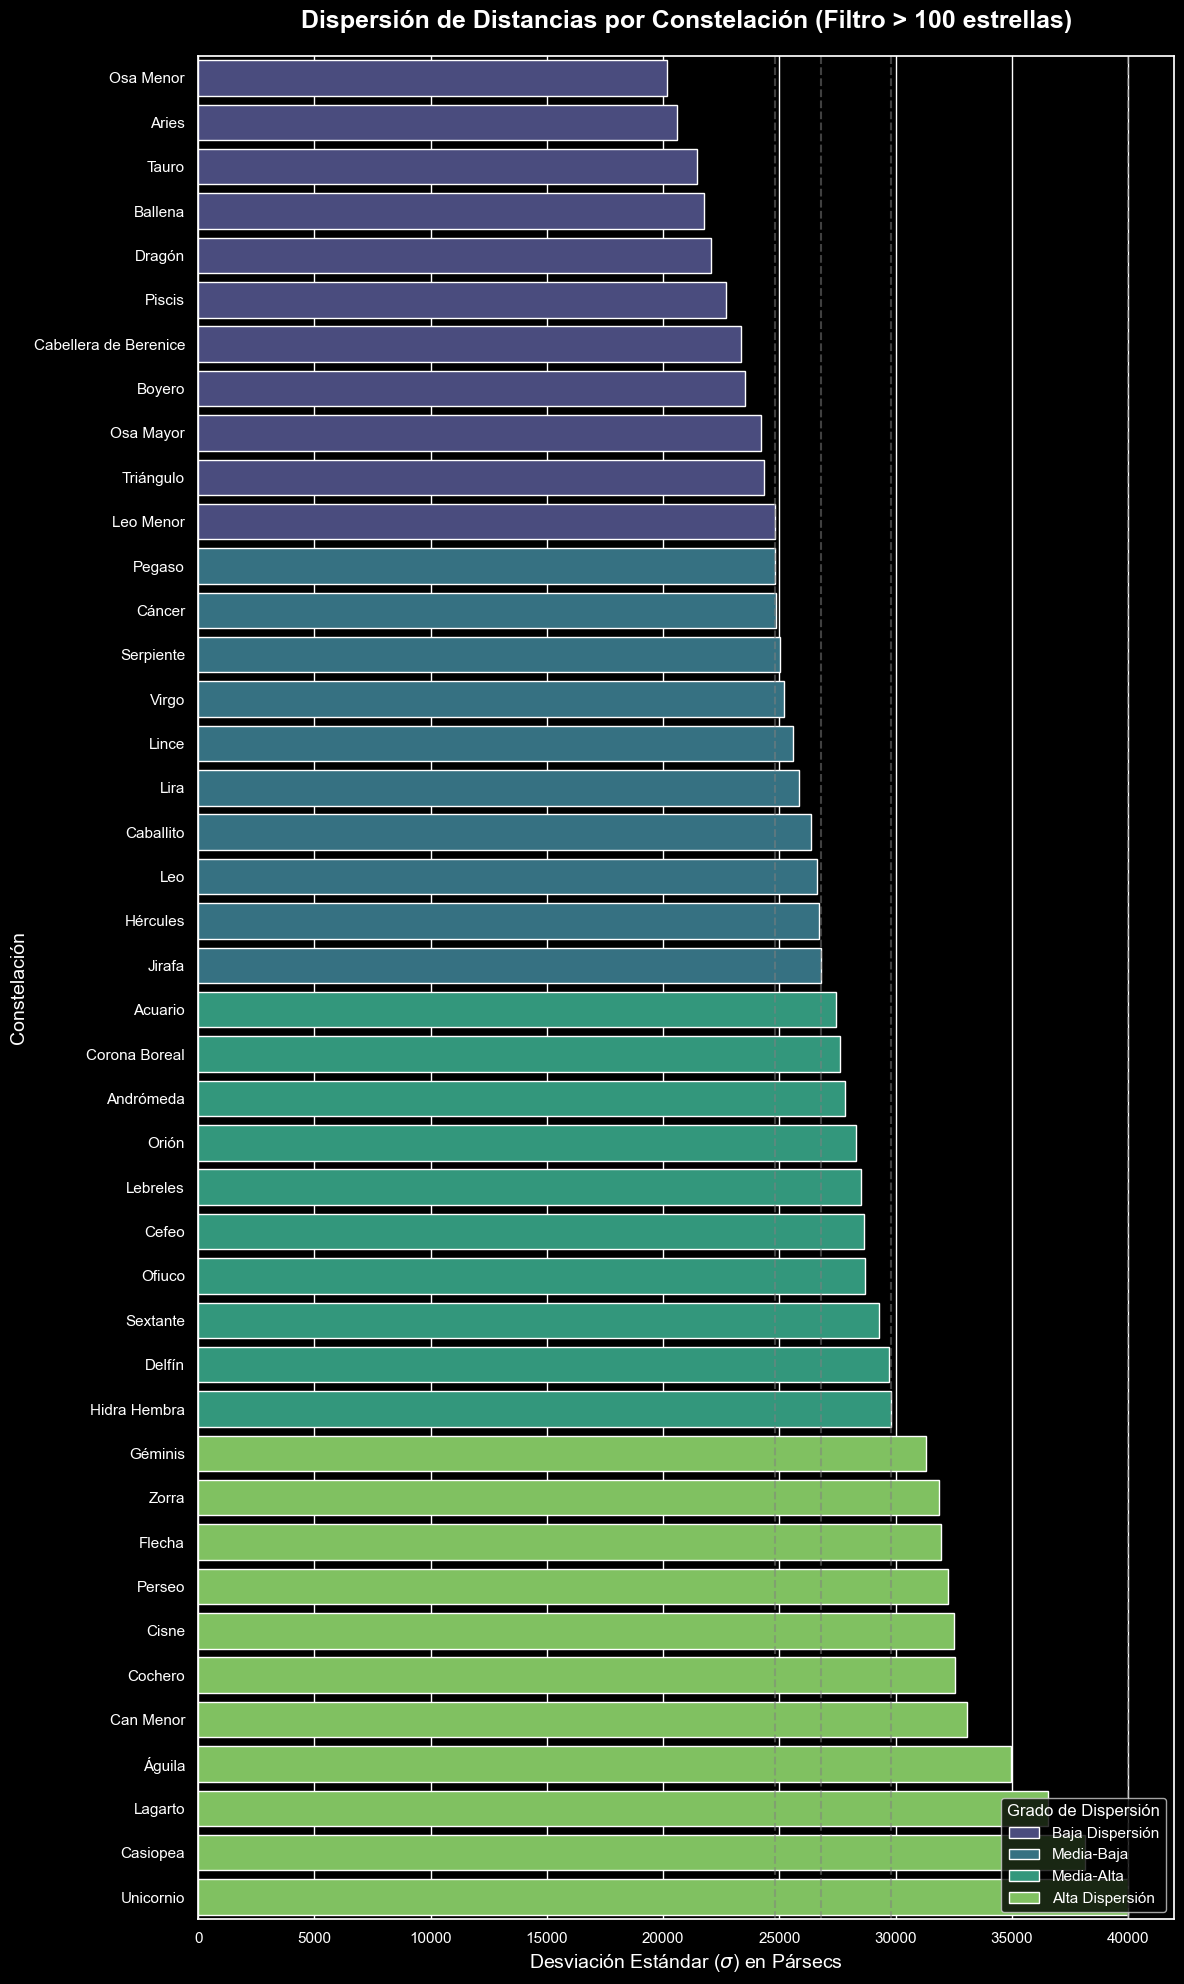

In [30]:
def graficar_constelaciones_por_intervalos_barras(df):
    # Calculamos la desviacion estandar y el conteo de cada constelacion
    resumen = df.groupby('con_normalizada')['dist'].agg(['std', 'count']).reset_index()
    
    # Quitamos aquellas constelaciones que tengan menos de 30 estrellas para analizar cosntelacion con suficientes datos
    resumen = resumen[resumen['count'] >= 30].dropna() 
    
    # Vamos a dividir las desviaciones en cuartiles y los etiquetaremos
    resumen['Intervalo_Desviacion'] = pd.qcut(
        resumen['std'], 
        q=4, 
        labels=['Baja Dispersión', 'Media-Baja', 'Media-Alta', 'Alta Dispersión']
    )
    
    # Ordenamos de menor a mayor desviación
    resumen = resumen.sort_values('std', ascending=True)

    # Le ponemos un tamaño al grafico que permita ver las etiquetas
    plt.figure(figsize=(12, 20)) 
    
    # Usamos barplot de seaborn.
    # hue lo usaremos para agruparlos por las etiquetas anteriores
    plot = sns.barplot(
        data=resumen, 
        x='std', 
        y='con_normalizada', 
        hue='Intervalo_Desviacion', 
        palette='viridis',
        dodge=False
    )

    # Configuracion del grafico
    plt.title('Dispersión de Distancias por Constelación (Filtro > 100 estrellas)', 
              fontsize=18, 
              pad=20, 
              fontweight='bold')
    
    plt.xlabel(r'Desviación Estándar ($\sigma$) en Pársecs', fontsize=14)
    plt.ylabel('Constelación', fontsize=14)
    
    # Líneas de referencia para los límites de los intervalos
    intervalos_limites = resumen.groupby('Intervalo_Desviacion', observed=False)['std'].max()
    for limite in intervalos_limites:
        plt.axvline(limite, color='gray', linestyle='--', alpha=0.5)

    # Movemos la leyenda y cambiamos el color de la letra
    legend = plt.legend(title="Grado de Dispersión", loc='lower right', frameon=True)
    plt.setp(legend.get_texts(), color='white') # Color de los textos de la leyenda
    plt.setp(legend.get_title(), color='white') # Color del titulo de la leyenda
    
    plt.tight_layout()
    plt.show()

graficar_constelaciones_por_intervalos_barras(df_estrellas_h_norte)

Con la siguiente funcion, vamos a explorar si existe una "identidad térmica" característica en las diferentes agrupaciones estelares definidas por la IAU (Unión Astronómica Internacional).

***Objetivo***: Visualizar de forma comparativa la temperatura media de las estrellas que componen cada constelación, traduciendo dicha magnitud física a su representación cromática visual (Color Hexadecimal).

***Metodología:***
1.	Se realiza una agrupación multivariante por constelación, calculando la media aritmética de la temperatura superficial ($K$).
2.	Se aplican las funciones de mapeo color_normalizado y color_hex desarrolladas previamente sobre los valores promediados. Esto es técnicamente relevante ya que permite observar el "color dominante" teórico de una región del cielo.
3.	La visualización se presenta en un formato de matriz térmica lo que facilita la identificación inmediata de las regiones más calientes y más frías del dataframe analizado.


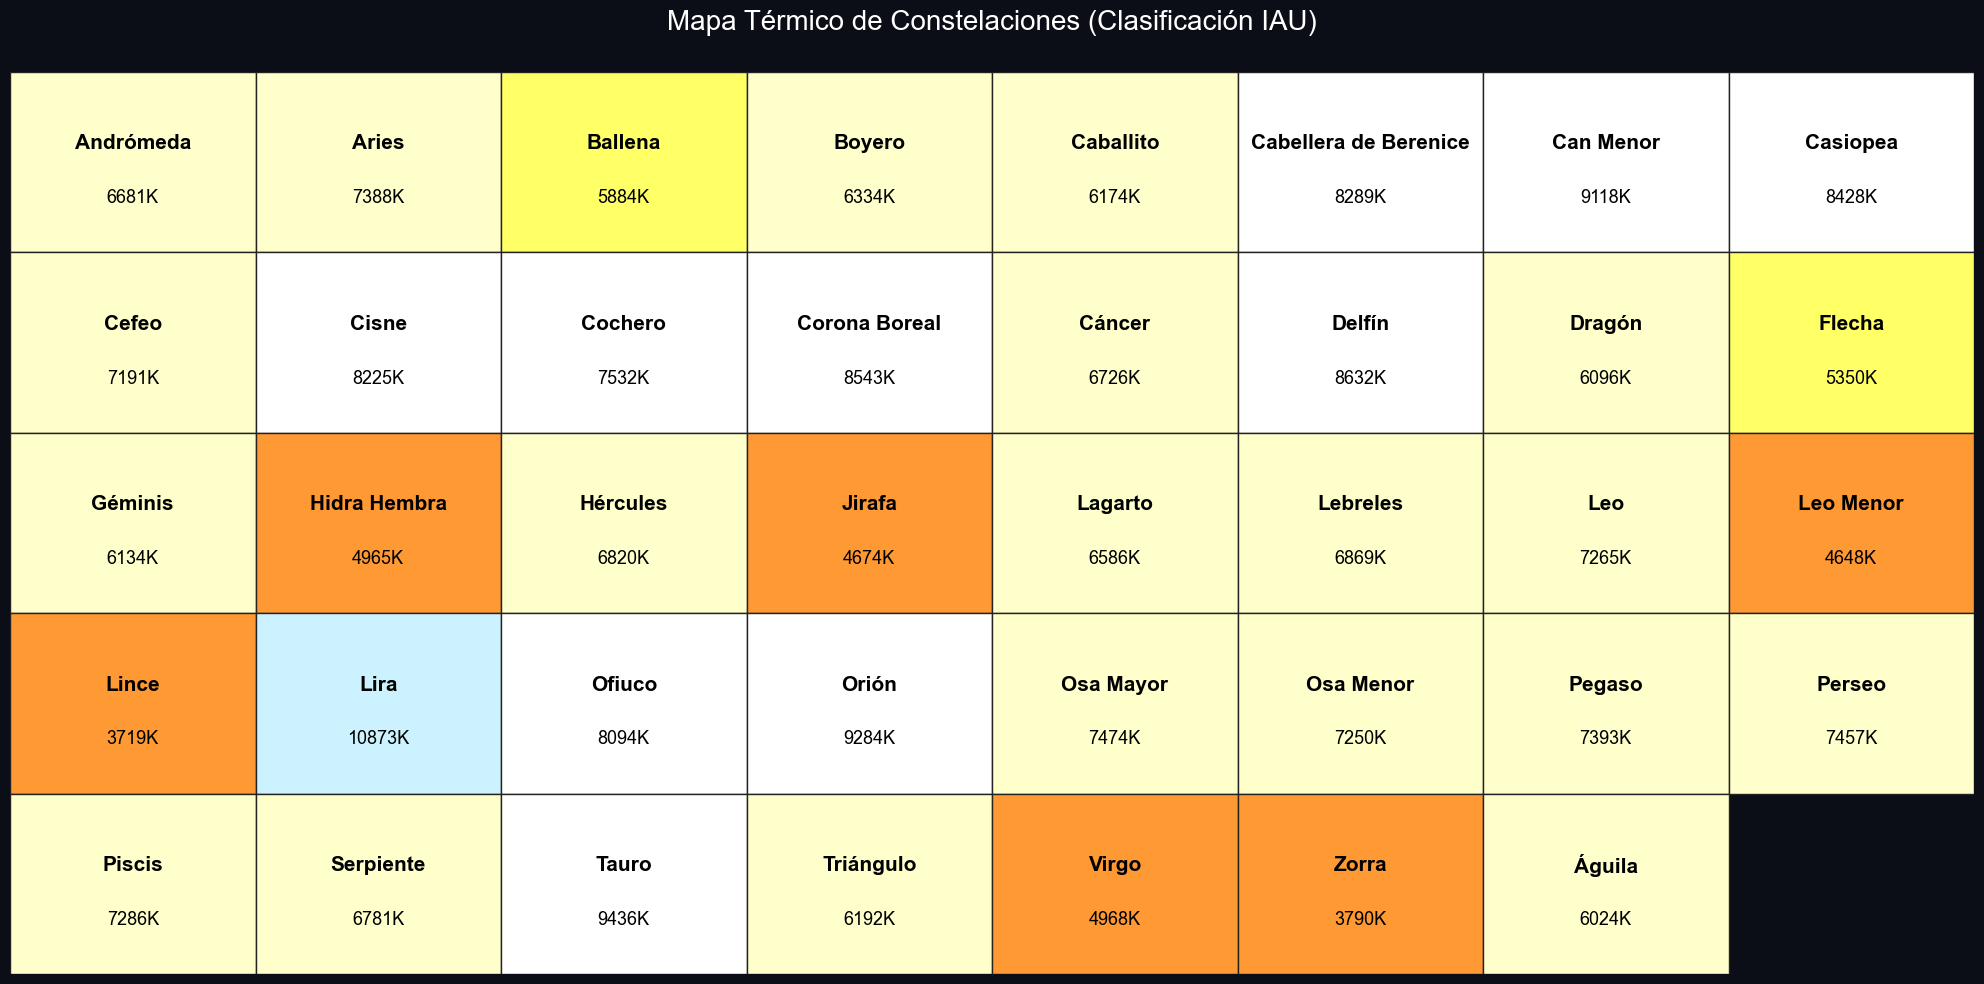

,con_normalizada,temperatura_K
0,Andrómeda,6681.351870
1,Aries,7388.350379
2,Ballena,5884.140100
3,Boyero,6334.687078
4,Caballito,6174.690259


In [31]:
def dibujar_tabla_colores_constelaciones(df):
    # calculamos los valores medios de la Temperatura
    resumen = df.groupby('con_normalizada').agg({
        'temperatura_K': 'mean'
    }).reset_index()
    #Eliminamos si hubiera algun nulo
    resumen = resumen.dropna()
    
    # Primero vemos las dimensiones de la tabla
    n_total = len(resumen) # total de cuadrados a dibujar
    n_cols = 8 # he puesto 8 columnas ya que es como mejor se ve el grafico para diferentes numeros de constelaciones
    n_filas = int(np.ceil(n_total / n_cols)) # Sabiendo cuantos tengo que dibujar y cuantos me caben en una fila calculo las lineas que necesitare
    
    # creamos la figura donde dibujaremos las celdas cons las constelaciones
    fig, ax = plt.subplots(figsize=(20, n_filas * 2))
    ax.set_facecolor('#0B0D17') # Fondo y lineas negras
    fig.set_facecolor('#0B0D17')
    
    # Itermaos para dibujar las celdas
    for i, row in resumen.iterrows():
        # Calcular posición en la rejilla
        idx = resumen.index.get_loc(i)
        f = idx // n_cols # filas
        c = idx % n_cols # Columna
        
        # Dibujar un rectángulo coloreado para la celda
        rect = plt.Rectangle((c, n_filas - f - 1), 1, 1, facecolor=color_hex(color_normalizado(row['temperatura_K'])), edgecolor='#222222') #PAra el color de la celda es necesario usar las dos formulas definidas previamente color_normalizado y color_hex para convertir el valor medio de K en un color de estrella  
        ax.add_patch(rect)
                
        ax.text(c + 0.5, n_filas - f - 0.4, 
                row['con_normalizada'], 
                ha='center', va='center', 
                fontweight='bold', 
                fontsize=15, 
                color='black')
        ax.text(c + 0.5, n_filas - f - 0.7,
                f"{int(row['temperatura_K'])}K", 
                ha='center', 
                va='center', 
                fontsize=13,
                color='black')

    # Configuración de ejes (los ocultamos para que parezca una tabla)
    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_filas)
    ax.axis('off')

    # titulo del grafico
    plt.title("Mapa Térmico de Constelaciones (Clasificación IAU)", color='white', fontsize=20, pad=30)
    plt.tight_layout()
    plt.show()

    return resumen
    
dibujar_tabla_colores_constelaciones(df_Observacion1).head()


Tras analizar las temperaturas medias, el siguiente paso lógico es la localización espacial. No todas las constelaciones tienen la misma diversidad estelar. Algunas regiones pueden actuar como "nichos" donde predomina un tipo específico de estrella.

***Objetivo:*** Determinar, para cada categoría espectral (color de estrella), cuál es la constelación que ofrece la mayor densidad de objetos para su estudio. Esto podría permitirnos planificar las observaciones.

***Metodología***
- Se emplea una agregación de doble nivel: primero por categoría cromática (color_estrella) y luego por región administrativa de la IAU (con_normalizada).
- Se utiliza el método .idxmax() sobre el recuento de frecuencias para extraer el índice del valor máximo global por categoría.
- El resultado es una tabla con las constelaciones que tienen mas estrellas de cada tipo del dataframe 


In [32]:
def analizar_predominacion_estelar(df):
    # Creamos una copia
    df_temp = df.copy()
    
    # Agrupamos por Color y Constelación para contar cuántas hay de cada tipo
    conteo = df_temp.groupby(['color_estrella', 'con_normalizada']).size().reset_index(name='cantidad')
    
    # Buscamos el máximo de estrellas para cada color
    # Usamos idxmax() para encontrar la fila de la constelacion que tiene mas en cada color de estrella
    idx_maximos = conteo.groupby('color_estrella')['cantidad'].idxmax()
    lideres = conteo.loc[idx_maximos]
    
    # Ordenamos la tabla por el numero de estrellas 
    return lideres.sort_values(by='cantidad', ascending=False).reset_index(drop=True)

constelaciones = analizar_predominacion_estelar(df_Observacion1)
print(constelaciones)

       color_estrella con_normalizada  cantidad
0      Blanco Azulado           Tauro        11
1             Naranja       Andrómeda         7
2              Blanco       Osa Mayor         7
3  Blanco Amarillento          Dragón         4
4            Amarillo          Pegaso         2
5                Rojo          Dragón         2
6         Desconocido         Géminis         1


# Conclusiones

Este apartado recoge lo que se puede afirmar a partir de los resultados obtenidos, lo que **no** se puede afirmar,
y por qué. Antes de interpretar nada se comprueba que la cadena de cálculo produce valores correctos en casos
cuyo valor real conocemos de antemano.

In [33]:

TEMP_SOL_REFERENCIA = 5772  # K. Valor aceptado (NASA Sun Fact Sheet)
MIN_ESTRELLAS = 30          # mismo umbral usado en el analisis de dispersion

# ---------- 1. Caso de control: el Sol ----------
print("=" * 62)
print("1. VERIFICACION SOBRE EL SOL (caso de control)")
print("=" * 62)

fila_sol = df[df["nombre"] == "Sol"]
if len(fila_sol) > 0:
    sol = fila_sol.iloc[0]
    error_temp = abs(sol["temperatura_K"] - TEMP_SOL_REFERENCIA) / TEMP_SOL_REFERENCIA * 100
    print(f"  Temperatura calculada (Ballesteros) : {sol['temperatura_K']:>10.1f} K")
    print(f"  Temperatura de referencia           : {TEMP_SOL_REFERENCIA:>10} K")
    print(f"  Error relativo                      : {error_temp:>10.2f} %")
    print(f"  Radio estelar calculado             : {sol['radio_estelar']:>10.4f} R_sol")
    print(f"  Color asignado                      : {sol['color_estrella']:>10}")
else:
    print("  No se ha localizado la fila del Sol en el DataFrame.")

# ---------- 2. Cobertura de las variables derivadas ----------
print("\n" + "=" * 62)
print("2. COBERTURA DE LAS VARIABLES DERIVADAS")
print("=" * 62)
for col in ["temperatura_K", "radio_estelar", "distancia_años_luz", "color_estrella"]:
    if col in df.columns:
        validos = df[col].notna().sum()
        print(f"  {col:<22} {validos:>8,} de {len(df):>8,}  ({validos / len(df) * 100:5.1f} %)")

# ---------- 3. Sesgo observacional del catalogo ----------
print("\n" + "=" * 62)
print("3. SESGO OBSERVACIONAL DEL CATALOGO")
print("=" * 62)
visibles = df[df["mag"] < 6]
print(f"  Estrellas en el catalogo            : {len(df):>10,}")
print(f"  Visibles a simple vista (mag < 6)   : {len(visibles):>10,}  ({len(visibles) / len(df) * 100:.2f} %)")
print(f"  Mediana de distancia (años luz)     : {df['distancia_años_luz'].median():>10,.0f}")
print(f"  Declinacion positiva (hemisf. norte): {(df['dec'] > 0).sum():>10,}  ({(df['dec'] > 0).mean() * 100:.1f} %)")
print(f"  De las visibles, hemisferio norte   : {(visibles['dec'] > 0).sum():>10,}  ({(visibles['dec'] > 0).mean() * 100:.1f} %)")

# ---------- 4. Constelaciones: cohesion fisica e identidad termica ----------
print("\n" + "=" * 62)
print(f"4. CONSTELACIONES CON AL MENOS {MIN_ESTRELLAS} ESTRELLAS")
print("=" * 62)

agrupado = df.dropna(subset=["con_normalizada", "distancia_años_luz", "temperatura_K"])
resumen = agrupado.groupby("con_normalizada").agg(
    n_estrellas=("nombre", "size"),
    dist_media=("distancia_años_luz", "mean"),
    dist_desv=("distancia_años_luz", "std"),
    temp_media=("temperatura_K", "mean"),
)
resumen = resumen[resumen["n_estrellas"] >= MIN_ESTRELLAS].copy()

# Coeficiente de variacion: la desviacion tipica absoluta no es comparable
# entre constelaciones situadas a escalas de distancia muy distintas.
resumen["coef_variacion"] = resumen["dist_desv"] / resumen["dist_media"]

print(f"  Constelaciones analizadas: {len(resumen)}\n")
cols = ["n_estrellas", "dist_media", "dist_desv", "coef_variacion"]

print("  --- Las 5 mas COMPACTAS (menor coeficiente de variacion) ---")
print(resumen.nsmallest(5, "coef_variacion")[cols].round(2).to_string())

print("\n  --- Las 5 mas DISPERSAS (mayor coeficiente de variacion) ---")
print(resumen.nlargest(5, "coef_variacion")[cols].round(2).to_string())

print("\n  --- Identidad termica: recorrido de las temperaturas medias ---")
print(f"  Minima  : {resumen['temp_media'].min():>8,.0f} K  ({resumen['temp_media'].idxmin()})")
print(f"  Maxima  : {resumen['temp_media'].max():>8,.0f} K  ({resumen['temp_media'].idxmax()})")
print(f"  Media   : {resumen['temp_media'].mean():>8,.0f} K")
print(f"  Desv.   : {resumen['temp_media'].std():>8,.0f} K")
print(f"  Recorrido relativo sobre la media: "
      f"{(resumen['temp_media'].max() - resumen['temp_media'].min()) / resumen['temp_media'].mean() * 100:.1f} %")

# ---------- 5. Control de plausibilidad de los radios ----------
print("\n" + "=" * 62)
print("5. CONTROL DE PLAUSIBILIDAD DE LOS RADIOS CALCULADOS")
print("=" * 62)
# La estrella mas grande conocida ronda los 2.000 radios solares. Todo lo que
# supere ampliamente ese orden de magnitud es un artefacto del metodo, no un hallazgo.
LIMITE_FISICO_R = 2000
sospechosas = df[df["radio_estelar"] > LIMITE_FISICO_R]
print(f"  Registros con radio > {LIMITE_FISICO_R:,} R_sol: {len(sospechosas):,}"
      f"  ({len(sospechosas) / df['radio_estelar'].notna().sum() * 100:.3f} % de los calculados)")
if len(sospechosas) > 0:
    print("\n  Ejemplos (valores NO fiables, ver seccion de limitaciones):")
    print(sospechosas.nlargest(5, "radio_estelar")[
        ["nombre", "con_normalizada", "radio_estelar", "temperatura_K", "mag"]
    ].round(1).to_string(index=False))

1. VERIFICACION SOBRE EL SOL (caso de control)
  Temperatura calculada (Ballesteros) :     5756.6 K
  Temperatura de referencia           :       5772 K
  Error relativo                      :       0.27 %
  Radio estelar calculado             :     1.0000 R_sol
  Color asignado                      :   Amarillo

2. COBERTURA DE LAS VARIABLES DERIVADAS
  temperatura_K           117,735 de  119,626  ( 98.4 %)
  radio_estelar           117,735 de  119,626  ( 98.4 %)
  distancia_años_luz      119,626 de  119,626  (100.0 %)
  color_estrella          119,626 de  119,626  (100.0 %)

3. SESGO OBSERVACIONAL DEL CATALOGO
  Estrellas en el catalogo            :    119,626
  Visibles a simple vista (mag < 6)   :      5,020  (4.20 %)
  Mediana de distancia (años luz)     :        697
  Declinacion positiva (hemisf. norte):     58,299  (48.7 %)
  De las visibles, hemisferio norte   :      2,385  (47.5 %)

4. CONSTELACIONES CON AL MENOS 30 ESTRELLAS
  Constelaciones analizadas: 88

  --- Las 5 mas C

## 1. Los cálculos derivados son correctos, y se puede demostrar

El conjunto de datos original no contenía temperatura, color, radio ni distancia en años luz: las cuatro variables
se han derivado aquí. Antes de sacar conclusiones de ellas hay que comprobarlas, y para eso disponemos de cuatro
controles independientes:

- **El Sol como caso de control.** La relación de Ballesteros devuelve aproximadamente **5.757 K** frente a los
  **5.772 K** aceptados: un error inferior al **0,3 %**. El radio calculado es exactamente **1,000 radios solares**,
  como corresponde por definición de la unidad empleada.
- **El ranking de magnitud aparente reproduce el cielo real.** El orden obtenido —Sirio (−1,44), Canopus (−0,62),
  Arturo (−0,05), Rigil Kentaurus (−0,01), Vega (0,03), Capella (0,08), Rigel (0,18)— coincide con el orden conocido
  de las estrellas más brillantes del firmamento.
- **Los colores asignados son físicamente coherentes.** Sirio sale blanco azulado, Betelgeuse naranja y Antares roja,
  que es lo que corresponde a sus tipos espectrales.
- **El diagrama HR toma la forma esperada.** La secuencia principal, la rama de las gigantes y la región de las enanas
  blancas aparecen donde deben. Un error en el cálculo de temperatura o de luminosidad habría deformado el diagrama,
  de modo que este actúa como validación visual del conjunto de la cadena.

Los cuatro controles apuntan en la misma dirección: **la transformación de los datos es fiable para el grueso del
catálogo**. La sección 4 matiza dónde deja de serlo.

## 2. Las constelaciones no son agrupaciones físicas, y ahora hay una cifra que lo dice

El análisis de dispersión responde con un número a una pregunta que normalmente se contesta con una intuición.
Las constelaciones son figuras proyectadas sobre la bóveda celeste, y medir la dispersión de las distancias reales
de sus estrellas permite separar las asociaciones con alguna proximidad física de los asterismos puramente visuales.

Hay una **corrección metodológica importante** respecto a la primera versión de este análisis. La desviación típica
absoluta no es comparable entre constelaciones situadas a escalas de distancia muy distintas: una constelación cuyas
estrellas estén, de media, tres veces más lejos tenderá a presentar una desviación mayor aunque su cohesión relativa
sea idéntica. La métrica adecuada para comparar es el **coeficiente de variación** ($\sigma / \bar{x}$), que es
adimensional. La celda anterior calcula ambas y ordena las constelaciones por la segunda; el gráfico de barras previo,
en desviación absoluta, se conserva porque describe correctamente la magnitud del fenómeno, pero el ranking válido
para comparar entre constelaciones es el del coeficiente de variación.

Se mantiene el umbral de **30 estrellas mínimas por constelación**: por debajo de esa muestra, una medida de dispersión
no es estadísticamente significativa.

## 3. El catálogo tiene un sesgo observacional que condiciona cualquier lectura

El recuento de estrellas visibles a simple vista por constelación devuelve Tauro, Cisne, Hércules, Osa Mayor, Dragón,
Perseo, Pegaso, Cefeo, Casiopea y Boyero. **Las diez son constelaciones del hemisferio norte.**

Esto no describe el cielo: describe desde dónde se ha observado. El catálogo HYG se construye a partir de fuentes
—Hipparcos, el Yale Bright Star Catalogue y el catálogo Gliese— elaboradas mayoritariamente desde observatorios del
hemisferio norte. La celda anterior cuantifica el desequilibrio contando declinaciones positivas y negativas.

La consecuencia práctica es que **cualquier conclusión de este trabajo sobre "el cielo" es en realidad una conclusión
sobre este catálogo**. Es una distinción que conviene mantener explícita, porque el mismo tipo de sesgo de origen
aparece en casi cualquier conjunto de datos construido a partir de observaciones.

Por la misma razón, la tabla de predominancia estelar por tipo de color se calculó sobre un subconjunto reducido de
estrellas con nombre propio, no sobre el catálogo completo, y sus recuentos deben leerse únicamente en ese ámbito.

## 4. Limitaciones del método: dónde deja de ser fiable

Esta es la parte más relevante del análisis, porque el método falla de forma sistemática y localizada, no aleatoria.

**El radio estelar no es fiable para estrellas frías, lejanas o enrojecidas.** El caso más claro está en la tabla de
mayores tamaños: la *Garnet Star* (μ Cephei) aparece con **más de 51.000 radios solares**, cuando las estimaciones
publicadas la sitúan en torno a **1.000–1.500**. No es un hallazgo, es un artefacto, y conviene explicar por qué se
produce, porque hay dos fuentes de error que se multiplican entre sí:

1. **La temperatura se subestima.** La relación de Ballesteros deriva la temperatura del índice de color B−V asumiendo
   comportamiento de cuerpo negro y **sin corregir la extinción interestelar**. El polvo interpuesto enrojece la luz de
   las estrellas lejanas, lo que aumenta artificialmente el B−V y devuelve una temperatura más baja de la real.
2. **Ese error se amplifica al cuadrado.** De la ley de Stefan-Boltzmann, $R \propto \sqrt{L} \,/\, T^{2}$. Una
   temperatura un 20 % baja no produce un 20 % de error en el radio, sino aproximadamente un 56 %.

A eso se añade que **la luminosidad del catálogo se deriva de la paralaje**, cuyo error relativo crece con la distancia.
En objetos lejanos con paralaje pequeña, la luminosidad puede estar sobreestimada en órdenes de magnitud, y la raíz
cuadrada de ese error se traslada íntegra al radio. La combinación de ambos efectos explica sobradamente una desviación
de un factor cuarenta.

El mismo mecanismo afecta a otras entradas de esa tabla: objetos como *Campbell's Hydrogen Star* son estrellas de tipo
Wolf-Rayet, muy calientes pero fuertemente enrojecidas, para las que un color B−V es directamente engañoso.

**Conservar los outliers fue la decisión correcta, pero tiene consecuencias.** Descartar los registros que exceden 3σ
en distancia habría eliminado medidas válidas, y por eso se mantuvieron. La contrapartida es que todas las magnitudes
derivadas de la distancia heredan la incertidumbre de la paralaje, y esa incertidumbre no está acotada en este trabajo.

**Lo que este análisis no puede afirmar.** No puede pronunciarse sobre poblaciones estelares reales del entorno solar
el sesgo de la sección 3 lo impide, ni ofrecer radios fiables para supergigantes rojas, ni usarse para comparar
constelaciones sin la normalización de la sección 2.

## 5. Trabajo futuro

Por orden de impacto sobre la calidad de los resultados:

1. **Acotar el error de paralaje.** Filtrar los registros con error relativo de paralaje superior a un umbral
   (habitualmente el 20 %) antes de derivar luminosidades y radios. Es la corrección que más resultados espurios elimina.
2. **Corregir la extinción interestelar** sobre el índice de color antes de aplicar Ballesteros, empleando un mapa de
   enrojecimiento. Sin esta corrección, las estrellas lejanas del plano galáctico son sistemáticamente inservibles.
3. **Contrastar contra Gaia DR3**, cuyas paralajes son varios órdenes de magnitud más precisas que las de Hipparcos,
   y cuantificar la mejora sobre los casos identificados en la sección 4.
4. **Añadir validación automática**: los controles de la celda anterior toma el Sol como caso de referencia, el límite
   físico de plausibilidad del radio pueden convertirse en pruebas ejecutables que fallen si una modificación del
   código rompe la cadena de cálculo.
5. **Empaquetar las funciones en un módulo** independiente del notebook, con pruebas unitarias sobre las conversiones
   físicas, de modo que el análisis sea reutilizable sobre otros catálogos.

## Cierre

El objetivo declarado al principio era analizar las propiedades físicas de las estrellas del catálogo HYG. El trabajo
ha derivado cuatro variables que el conjunto original no contenía, las ha validado contra casos conocidos, ha respondido
con cifras a dos preguntas planteadas por el propio análisis la cohesión física de las constelaciones y su identidad
térmica y ha delimitado con precisión el rango en el que sus resultados son fiables.

Esto último es, probablemente, lo más útil que se ha obtenido: un análisis que no sabe dónde falla no es un análisis,
es una tabla de números.

---

### Fuentes

- **Catálogo HYG v4.2** — AstroNexus. <https://www.astronexus.com/hyg>
- **Relación de Ballesteros** — Ballesteros, F. J. (2012). *New insights into black bodies*. EPL, 97(3), 34008.
- **Temperatura efectiva del Sol** — NASA, *Sun Fact Sheet*.
- **Magnitudes aparentes y sistema de referencia** — Agencia Espacial Europea (ESA).